# ViHSD — Vietnamese Hate-Speech Detection
## Project Presentation

---

**📌 Language note:** every part of this project — the training data, the models, and the live demo — operates on **Vietnamese-language text** (real Vietnamese social-media comments). Nothing is translated at any step; models are trained, evaluated, and demoed directly in Vietnamese.

**What this is.** We built and compared several machine-learning models that automatically classify Vietnamese social-media comments as `CLEAN`, `OFFENSIVE`, or `HATE` speech, using the public `ViHSD` benchmark (~33,400 real Vietnamese comments).

**Why it matters.** Manual moderation of Vietnamese-language content doesn't scale. A reliable automatic classifier — tuned to catch real `HATE` speech even at some cost in false positives — reduces moderator workload and platform risk.

**How to read this notebook.**

| If you want... | Go to |
|---|---|
| The bottom line — which model wins, how good is it | **Part 7** — Final Model: Official Test-Set Results |
| To see it work on real Vietnamese text | **Part 8** — Live Demo |
| To run that demo again later, without retraining | **Part 7B** — Persist the Model, then Part 8 |
| The full technical methodology | **Parts 3–6** |
| What changed since the last run / reproducibility | **Appendix B** |



In [1]:
!pip install -q \
  "transformers==4.57.6" \
  "huggingface-hub==0.36.2" \
  "datasets" \
  "scikit-learn" \
  "scipy" \
  "gradio==5.50.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 145.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.6/325.6 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.4/462.4 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 142.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 119.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is 

In [2]:
# Environment check — surface a missing dependency here, not three stages deep.
import sys
import sklearn
import torch
import transformers

print(f"python       : {sys.version.split()[0]}")
print(f"torch        : {torch.__version__}")
print(f"transformers : {transformers.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
if torch.cuda.is_available():
    print(f"device       : cuda — {torch.cuda.get_device_name(0)}")
else:
    print("device       : cpu — stage 2 chay duoc; stage 3/6 se rat cham, dung dung may nay")

python       : 3.13.15
torch        : 2.11.0+cu128
transformers : 4.57.6
scikit-learn : 1.6.1
device       : cuda — NVIDIA A100-SXM4-40GB


## Appendix A — Environment & Configuration (technical setup)

*Stakeholders can skip ahead to **Part 1** below — this section only installs dependencies and fixes the experiment parameters (`FOLDS = 5`, `SEED = 42`) that keep every stage comparable to run #1.*


In [3]:
from pathlib import Path
import os

# --- CV geometry: fixed project-wide, keep as-is for comparability with run #1 ---
SPLIT = "train"      # "train" (24,048) | "validation" (2,672) | "test" (6,680)
FOLDS = 5
SEED = 42
SAMPLE_SIZE = None   # first N examples, e.g. 2000 for a smoke run; None = the whole split

# --- Stage 2: classical TF-IDF baselines (unchanged from run #1) ---
CLASSICAL_MODELS = ("logreg", "svm")

# --- Stage 3: run #2 recipe. ~301 optimizer steps/epoch instead of run #1's ~38. ---
TRANSFORMER_MODELS = (
    {"model_name": "vinai/phobert-base", "freeze_embeddings": False},
    {"model_name": "uitnlp/visobert", "freeze_embeddings": False},
    {"model_name": "xlm-roberta-base", "freeze_embeddings": False},
)
BATCH_SIZE = 64
EPOCHS = 6.0                 # upper bound; early stopping decides the real count
LEARNING_RATE = 3e-5
MAX_LENGTH = 128
WARMUP_RATIO = 0.1
OPTIM = "adamw_torch"
GRAD_ACCUM_STEPS = 1
EARLY_STOPPING_PATIENCE = 2  # epochs without Macro F1 improvement on the held-out fold
LOAD_BEST_CHECKPOINT = True  # predict with the best epoch, not the final epoch
SAVE_TOTAL_LIMIT = 1         # keep only the best checkpoint per fold (disk)

# --- New stages ---
ENSEMBLE_PROB_MEMBERS = ("r2_visobert", "classical_logreg")            # probability averaging
ENSEMBLE_VOTE_MEMBERS = ("r2_visobert", "classical_logreg", "classical_svm")
HATE_RECALL_TARGET = 0.85    # Technical way of saying: we accept that 15 out of every 100 hateful comments pass the automatic rule unflagged, in exchange for a review queue we can actually staff
FINAL_BACKBONE = "uitnlp/visobert"

# --- Stage 3B: imbalance-handling ablation for the transformer ---
IMBALANCE_TECHNIQUES = ("vanilla", "class_weight", "focal", "focal_weighted")
IMBALANCE_FOLDS = (1,)
FOCAL_GAMMA = 2.0 # FOLCAL_GAMMA > 0: giảm trọng số của các sample dễ, tập trung hơn vào các sample khó / bị dự đoán sai.

# --- Stage 3C: learning-rate search with proof ---
LR_RANGE_START, LR_RANGE_END, LR_RANGE_STEPS = 1e-7, 1e-2, 300
LR_GRID = (1e-5, 2e-5, 3e-5, 5e-5)   # the range-test pick joins the grid automatically
LR_SEARCH_FOLD = 1
LR_CV_CONFIRM = False        # True = full 5-fold paired confirmation of BEST_LR (~2h extra)
USE_BEST_LR_IN_FINAL = True  # stage 6 trains with BEST_LR once the search has run

if os.path.exists("/kaggle/working"):
    OUT_ROOT = Path("/kaggle/working/outputs")   # Kaggle
else:
    OUT_ROOT = Path("/content/outputs")          # Colab
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# --- Part 7B / Part 8: persist the model so the demo never needs a retrain ---
DEMO_SCHEMA_VERSION = 1               # demo_config.json contract; mirrors src/vihate/demo_bundle.py
BUNDLE_DIR = OUT_ROOT / "demo_bundle"  # model/ + demo_config.json + README.md, self-contained
HF_MODEL_REPO = ""                     # e.g. "your-hf-user/vihsd-visobert"; "" = local bundle only
HF_REPO_PRIVATE = False                # True = push as a private repo (needs a write token)
DEMO_SOURCE = ""                       # Part 8 cold start: "" = BUNDLE_DIR, else a Hub repo id or path

## Part 1 — The Data: Vietnamese Hate-Speech Comments

**📌 Language note:** everything below is Vietnamese-language content. We use `uitnlp/vihsd`, a public benchmark of ~33,400 real Vietnamese social-media comments, each labeled `CLEAN` (0), `OFFENSIVE` (1), or `HATE` (2). Raw comment text is never modified — only labels are standardized.

The classes are imbalanced (~12 : 1.6 : 1, CLEAN : OFFENSIVE : HATE). That's why **Macro F1**, not plain accuracy, is our primary success metric — accuracy alone can look great while completely missing the rare `HATE` class.

### Stage 1 — Input: the ViHSD dataset

`uitnlp/vihsd`, ~33.4K bình luận tiếng Việt nhãn `CLEAN` (0) / `OFFENSIVE` (1) /
`HATE` (2).
Loader chỉ chuẩn hoá nhãn; văn bản giữ nguyên 100%.
Mất cân bằng ~12 : 1,6 : 1 là lý do Macro F1 là thước đo chính.

In [4]:
from datasets import load_dataset

LABEL_NAMES = ("CLEAN", "OFFENSIVE", "HATE")

try:  # dataset + weights are public; login only matters for gated mirrors
    from google.colab import userdata
    from huggingface_hub import login

    login(token=userdata.get("HF_Token"))
except Exception:
    print("HF login skipped (public access is enough)")


def normalize_label(raw_label):
    # Label parsing is the ONLY normalization this project allows.
    if isinstance(raw_label, int) and not isinstance(raw_label, bool):
        if raw_label in (0, 1, 2):
            return raw_label
        raise ValueError(f"unknown ViHSD label: {raw_label}")
    if isinstance(raw_label, str):
        key = raw_label.strip().upper()
        if key in LABEL_NAMES:
            return LABEL_NAMES.index(key)
        if key.isdigit():
            return normalize_label(int(key))
    raise ValueError(f"unknown ViHSD label: {raw_label}")


dataset = load_dataset("uitnlp/vihsd", split=SPLIT)
text_column = next(
    (c for c in ("text", "comment", "content", "sentence", "free_text") if c in dataset.column_names),
    None,
)
label_column = next(
    (c for c in ("label", "labels", "class", "category", "label_id") if c in dataset.column_names),
    None,
)
if text_column is None or label_column is None:
    raise RuntimeError(f"could not infer text/label columns from: {dataset.column_names}")

rows = dataset if SAMPLE_SIZE is None else dataset.select(range(min(SAMPLE_SIZE, len(dataset))))
texts = [str(row[text_column]) for row in rows]
labels = [normalize_label(row[label_column]) for row in rows]
print(f"uitnlp/vihsd split={SPLIT!r} columns=({text_column}, {label_column}) -> {len(texts):,} examples")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

dev.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/24048 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2672 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6680 [00:00<?, ? examples/s]

uitnlp/vihsd split='train' columns=(free_text, label_id) -> 24,048 examples


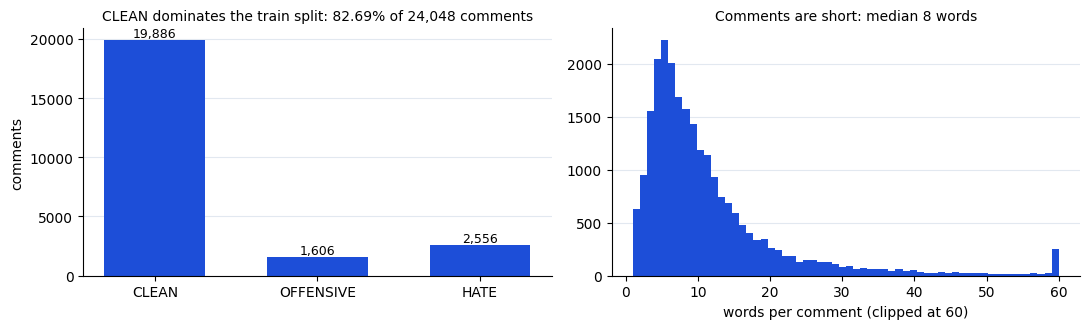

,label_id,label,count,share
0,0,CLEAN,19886,82.69%
1,1,OFFENSIVE,1606,6.68%
2,2,HATE,2556,10.63%


In [5]:
%matplotlib inline
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

MARK = "#1d4ed8"
counts = Counter(labels)
total = len(labels)

distribution = pd.DataFrame(
    {
        "label_id": list(range(len(LABEL_NAMES))),
        "label": list(LABEL_NAMES),
        "count": [counts.get(label_id, 0) for label_id in range(len(LABEL_NAMES))],
    }
)
distribution["share"] = [f"{count / total:.2%}" for count in distribution["count"]]
word_lengths = pd.Series([len(text.split()) for text in texts])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(distribution["label"], distribution["count"], color=MARK, width=0.62)
axes[0].set_title(f"CLEAN dominates the {SPLIT} split: {distribution['share'].iloc[0]} of {total:,} comments", fontsize=10)
axes[0].set_ylabel("comments")
for label, count in zip(distribution["label"], distribution["count"], strict=True):
    axes[0].text(label, count, f"{count:,}", ha="center", va="bottom", fontsize=9)
axes[1].hist(word_lengths.clip(upper=60), bins=60, color=MARK)
axes[1].set_title(f"Comments are short: median {int(word_lengths.median())} words", fontsize=10)
axes[1].set_xlabel("words per comment (clipped at 60)")
for ax in axes:
    ax.grid(axis="y", color="#e2e8f0", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()
distribution

In [6]:
from sklearn.model_selection import StratifiedKFold

# One splitter, shared by every model below: fold i of one model holds out exactly the same
splitter = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
fold_plan = []
for fold, (train_idx, test_idx) in enumerate(splitter.split(texts, labels), start=1):
    validation_fold = Counter(labels[idx] for idx in test_idx)
    fold_plan.append(
        {
            "fold": fold,
            "train": len(train_idx),
            "validation": len(test_idx),
            **{
                f"{label.lower()}": validation_fold.get(label_id, 0)
                for label_id, label in enumerate(LABEL_NAMES)
            },
        }
    )
print(f"StratifiedKFold(n_splits={FOLDS}, shuffle=True, random_state={SEED})")
pd.DataFrame(fold_plan)

StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


,fold,train,validation,clean,offensive,hate
0,1,19238,4810,3978,321,511
1,2,19238,4810,3977,321,512
2,3,19238,4810,3977,322,511
3,4,19239,4809,3977,321,511
4,5,19239,4809,3977,321,511


### How We Measure Success

A shared "measurement kit" (helper functions) is used by every model in this notebook, so every stage is scored the exact same way and results stay comparable.


In [7]:
import json
from statistics import fmean, pstdev

import numpy as np
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_fscore_support,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

OOF = {}  # run_name -> per-row out-of-fold store


def write_json(path, payload):
    with open(path, "w", encoding="utf-8") as fh:
        json.dump(payload, fh, ensure_ascii=False, indent=2)


def evaluate_fold(fold, y_true, y_pred, y_prob, out_dir):
    class_ids = [0, 1, 2]
    precision, recall, f1, _support = precision_recall_fscore_support(
        y_true, y_pred, labels=class_ids, average=None, zero_division=0
    )
    scalars = {
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }
    for idx, name in enumerate(LABEL_NAMES):
        scalars[f"{name.lower()}_precision"] = float(precision[idx])
        scalars[f"{name.lower()}_recall"] = float(recall[idx])
        scalars[f"{name.lower()}_f1"] = float(f1[idx])
    if y_prob is not None:
        truth = label_binarize(y_true, classes=class_ids)
        probabilities = np.asarray(y_prob, dtype=float)
        scalars["roc_auc_ovr_weighted"] = float(
            roc_auc_score(truth, probabilities, average="weighted", multi_class="ovr")
        )
        scalars["pr_auc_macro"] = float(average_precision_score(truth, probabilities, average="macro"))
    matrix = confusion_matrix(y_true, y_pred, labels=class_ids).astype(int).tolist()
    return {"fold": fold, "scalars": scalars, "confusion_matrix": matrix}


def summarize_folds(fold_scalars):
    names = sorted({name for scalars in fold_scalars for name in scalars})
    return {
        name: {
            "mean": fmean([s[name] for s in fold_scalars if name in s]),
            "std": pstdev([s[name] for s in fold_scalars if name in s]),
        }
        for name in names
    }


def empty_oof(n_rows):
    return {
        "prob": np.zeros((n_rows, len(LABEL_NAMES)), dtype=float),
        "pred": np.zeros(n_rows, dtype=int),
        "true": np.zeros(n_rows, dtype=int),
        "fold": np.zeros(n_rows, dtype=int),
        "count": np.zeros(n_rows, dtype=int),
        "prob_kind": "model",
    }


def fill_oof(store, indices, y_true, y_pred, y_prob, fold):
    idx = np.asarray(indices, dtype=int)
    store["true"][idx] = y_true
    store["pred"][idx] = y_pred
    store["prob"][idx] = y_prob
    store["fold"][idx] = fold
    store["count"][idx] += 1


def dump_oof(store, out_dir, run_name):
    write_json(
        out_dir / "oof.json",
        {
            "run": run_name,
            "prob_kind": store["prob_kind"],
            "fold": store["fold"].tolist(),
            "true": store["true"].tolist(),
            "pred": store["pred"].tolist(),
            "prob": store["prob"].tolist(),
        },
    )


def oof_fold_results(store, out_dir, run_name):
    # Turn an OOF store back into the same shape every model reports, so ensembles
    # join the leaderboard and the paired tests like any other run.
    assert (store["count"] == 1).all(), f"{run_name}: OOF coverage broken (a row seen != 1 time)"
    results = []
    for fold in range(1, FOLDS + 1):
        mask = store["fold"] == fold
        results.append(
            evaluate_fold(fold, store["true"][mask], store["pred"][mask], store["prob"][mask], out_dir)
        )
    return results

## Part 2 — Our Approach, at a Glance

Before diving into details, here's the shape of the project:

1. **Start simple.** Train a classical ML baseline (TF-IDF + linear model) on the Vietnamese comments.
2. **Go deeper.** Fine-tune transformer language models (XLM-R, ViSoBERT, PhoBert) directly on the same Vietnamese text, specifically addressing the class imbalance and tuning the learning rate with evidence rather than guesswork.
3. **Compare fairly.** Score every model the same way (Macro F1 + per-class recall) via 5-fold cross-validation.
4. **Combine and calibrate.** Ensemble the strongest models and tune the decision threshold specifically to catch `HATE` speech — a deliberate, safety-oriented choice, not just an accuracy play.
5. **Report once, honestly.** Train one final model and evaluate it a single time on the official held-out test set, so the reported number isn't inflated by repeated peeking.
6. **Show it working.** A live demo on real Vietnamese input.


## Part 3 — Baseline Model: Classical ML (TF-IDF)

We set a classical baseline: TF-IDF features + a linear model (and an SVM), trained directly on Vietnamese text. This tells us how much extra performance the far more expensive transformer models actually buy us.


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC


def build_classical_pipeline(model, seed):
    features = FeatureUnion(
        [
            ("word", TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=2)),
            ("char", TfidfVectorizer(analyzer="char", ngram_range=(3, 5), min_df=2)),
        ]
    )
    if model == "logreg":
        classifier = LogisticRegression(class_weight="balanced", max_iter=1_000, random_state=seed)
    else:  # "svm"
        classifier = LinearSVC(class_weight="balanced", random_state=seed)
    return Pipeline([("features", features), ("classifier", classifier)])


def run_classical_cv(model, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    fold_results = []
    store = empty_oof(len(texts))
    for fold, (train_idx, test_idx) in enumerate(splitter.split(texts, labels), start=1):
        pipeline = build_classical_pipeline(model, SEED)
        pipeline.fit([texts[i] for i in train_idx], [labels[i] for i in train_idx])
        test_texts = [texts[i] for i in test_idx]
        test_labels = [labels[i] for i in test_idx]
        predictions = pipeline.predict(test_texts)
        probabilities = pipeline.predict_proba(test_texts) if hasattr(pipeline, "predict_proba") else None
        if probabilities is None:
            probabilities = np.eye(len(LABEL_NAMES))[predictions]
            store["prob_kind"] = "one_hot(pred)"
        fill_oof(store, test_idx, test_labels, predictions, probabilities, fold)
        fold_results.append(evaluate_fold(fold, test_labels, predictions, probabilities, out_dir))
    run_name = f"classical_{model}"
    OOF[run_name] = store
    dump_oof(store, out_dir, run_name)
    return fold_results

In [9]:
import time

HEADLINE_METRICS = (
    "macro_f1",
    "weighted_f1",
    "balanced_accuracy",
    "mcc",
    "roc_auc_ovr_weighted",
    "pr_auc_macro",
)

all_runs = {}

for model in CLASSICAL_MODELS:
    out_dir = OUT_ROOT / f"classical_{model}"
    started = time.perf_counter()
    all_runs[f"classical_{model}"] = run_classical_cv(model, out_dir)
    print(f"classical_{model} done in {time.perf_counter() - started:.1f}s")


def fold_table(fold_results):
    rows = []
    for result in fold_results:
        row = {"fold": result["fold"]}
        for metric in HEADLINE_METRICS:
            row[metric] = round(result["scalars"][metric], 4) if metric in result["scalars"] else "n/a"
        rows.append(row)
    return pd.DataFrame(rows)


for run_name, fold_results in all_runs.items():
    print(run_name)
    display(fold_table(fold_results))

classical_logreg done in 106.4s
classical_svm done in 28.0s
classical_logreg


,fold,macro_f1,weighted_f1,balanced_accuracy,mcc,roc_auc_ovr_weighted,pr_auc_macro
0,1,0.6356,0.8528,0.6566,0.5258,0.9090,0.6598
1,2,0.6573,0.8592,0.6818,0.5516,0.9145,0.6732
2,3,0.6466,0.8554,0.6695,0.5391,0.9107,0.6772
3,4,0.6492,0.8538,0.6812,0.5409,0.9099,0.6810
4,5,0.6520,0.8568,0.6714,0.5381,0.9105,0.6691


classical_svm


,fold,macro_f1,weighted_f1,balanced_accuracy,mcc,roc_auc_ovr_weighted,pr_auc_macro
0,1,0.6454,0.8658,0.6157,0.5424,0.7639,0.5096
1,2,0.6556,0.8701,0.6309,0.5615,0.7789,0.5205
2,3,0.6410,0.8642,0.6153,0.5429,0.7658,0.5091
3,4,0.6622,0.8707,0.6423,0.5646,0.7840,0.5263
4,5,0.6585,0.8688,0.6313,0.5541,0.7739,0.5196


## Part 4 — Fine-Tuning Transformer Models

We fine-tune transformer language models (XLM-R, ViSoBERT) directly on Vietnamese comments — no translation step involved.

### Stage 3 — Transformer fine-tuning (cần GPU)

1. `per_device_train_batch_size = 64`;
2. `num_train_epochs = 6` là trần, `EarlyStoppingCallback(patience=2)` quyết định điểm dừng;
3. `save_strategy="epoch"` + `load_best_model_at_end=True` + `metric_for_best_model="macro_f1"`
   → `trainer.predict` dùng trọng số của epoch tốt nhất;
4. `MAX_LENGTH = 128` dùng cho cả huấn luyện lẫn suy diễn;


In [10]:
import torch
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)


def load_tokenizer(model_name):
    # Slow tokenizer first: the fast ones for PhoBERT/XLM-R are why the project pins
    # transformers<5.
    try:
        return AutoTokenizer.from_pretrained(model_name, use_fast=False)
    except (ValueError, OSError, ImportError):
        return AutoTokenizer.from_pretrained(model_name, use_fast=True)


def class_weights(train_labels):
    # Inverse class frequency from THIS fold's training labels only — leak-free.
    counts = torch.bincount(torch.tensor(train_labels), minlength=3).float()
    return counts.sum() / (counts.clamp_min(1.0) * 3.0)


def weighted_loss_trainer_class(weights):
    class WeightedLossTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
            batch_labels = inputs.pop("labels")
            outputs = model(**inputs)
            loss_fn = torch.nn.CrossEntropyLoss(weight=weights.to(outputs.logits.device))
            loss = loss_fn(outputs.logits.view(-1, 3), batch_labels.view(-1))
            return (loss, outputs) if return_outputs else loss

    return WeightedLossTrainer


def macro_f1_metric(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=-1)
    return {
        "macro_f1": float(f1_score(eval_pred.label_ids, predictions, average="macro", zero_division=0))
    }


def epoch_history(trainer):
    by_epoch = {}
    for record in trainer.state.log_history:
        epoch = record.get("epoch")
        if epoch is None:
            continue
        row = by_epoch.setdefault(round(float(epoch), 4), {"epoch": round(float(epoch), 4)})
        for key in ("loss", "eval_loss", "eval_macro_f1"):
            if key in record:
                row[key] = float(record[key])
    return [by_epoch[key] for key in sorted(by_epoch)]

In [11]:
import time


def run_transformer_cv(run_config, out_dir, trainer_factory=None, folds=None,
                       run_name=None, collect_oof=True, learning_rate=None):
    # trainer_factory: callable(train_labels) -> Trainer subclass (imbalance ablation)
    # folds: subset of fold ids to run (LR search / ablation); None = all FOLDS
    # collect_oof=False skips the OOF store (partial-fold runs must not claim coverage)
    model_name = run_config["model_name"]
    run_name = run_name or ("r2_" + model_name.split("/")[-1])
    lr = LEARNING_RATE if learning_rate is None else learning_rate
    out_dir.mkdir(parents=True, exist_ok=True)
    tokenizer = load_tokenizer(model_name)
    collator = DataCollatorWithPadding(tokenizer, pad_to_multiple_of=8)
    use_fp16 = torch.cuda.is_available()
    fold_results, history = [], []
    store = empty_oof(len(texts)) if collect_oof else None

    fold_pairs = list(enumerate(splitter.split(texts, labels), start=1))
    if folds is not None:
        fold_pairs = [pair for pair in fold_pairs if pair[0] in set(folds)]

    for fold, (train_idx, test_idx) in fold_pairs:
        train_labels = [labels[i] for i in train_idx]
        test_labels = [labels[i] for i in test_idx]

        def tokenize(batch):
            return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

        train_ds = Dataset.from_dict({"text": [texts[i] for i in train_idx], "label": train_labels})
        test_ds = Dataset.from_dict({"text": [texts[i] for i in test_idx], "label": test_labels})
        train_ds = train_ds.map(tokenize, batched=True, remove_columns=["text"])
        test_ds = test_ds.map(tokenize, batched=True, remove_columns=["text"])

        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
        if run_config["freeze_embeddings"]:
            for parameter in model.get_input_embeddings().parameters():
                parameter.requires_grad = False
        args = TrainingArguments(
            output_dir=str(out_dir / f"fold_{fold}"),
            eval_strategy="epoch",
            logging_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=LOAD_BEST_CHECKPOINT,
            metric_for_best_model="macro_f1",
            greater_is_better=True,
            save_total_limit=SAVE_TOTAL_LIMIT,
            learning_rate=lr,
            per_device_train_batch_size=BATCH_SIZE,
            per_device_eval_batch_size=256,
            gradient_accumulation_steps=GRAD_ACCUM_STEPS,
            num_train_epochs=EPOCHS,
            lr_scheduler_type="linear",
            warmup_ratio=WARMUP_RATIO,
            optim=OPTIM,
            gradient_checkpointing=False,
            fp16=use_fp16,
            seed=SEED,
            report_to=[],
        )
        trainer_cls = (
            trainer_factory(train_labels)
            if trainer_factory is not None
            else weighted_loss_trainer_class(class_weights(train_labels))
        )
        trainer = trainer_cls(
            model=model,
            args=args,
            train_dataset=train_ds,
            eval_dataset=test_ds,
            data_collator=collator,
            compute_metrics=macro_f1_metric,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
        )
        trainer.train()
        history.append({"fold": fold, "epochs": epoch_history(trainer)})

        # With load_best_model_at_end this predicts with the best-epoch weights.
        output = trainer.predict(test_ds)
        probabilities = torch.softmax(torch.tensor(output.predictions), dim=-1).numpy()
        predictions = np.argmax(probabilities, axis=-1)
        if collect_oof:
            fill_oof(store, test_idx, test_labels, predictions, probabilities, fold)
        fold_results.append(evaluate_fold(fold, test_labels, predictions, probabilities, out_dir))
        print(f"fold {fold}/{FOLDS}: macro_f1 {fold_results[-1]['scalars']['macro_f1']:.4f}")

    if collect_oof:
        OOF[run_name] = store
        dump_oof(store, out_dir, run_name)
    write_json(out_dir / "history.json", history)
    return run_name, fold_results

In [12]:
import time

for run_config in TRANSFORMER_MODELS:
    run_name = "r2_" + run_config["model_name"].split("/")[-1]
    out_dir = OUT_ROOT / run_name
    started = time.perf_counter()
    print(run_config["model_name"])
    name, fold_results = run_transformer_cv(run_config, out_dir)
    all_runs[name] = fold_results
    macro = [r["scalars"]["macro_f1"] for r in fold_results]
    print(f"done in {time.perf_counter() - started:.1f}s   macro_f1 per fold: {macro}")

vinai/phobert-base


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/19239 [00:00<?, ? examples/s]

Map:   0%|          | 0/4809 [00:00<?, ? examples/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,1.001800,0.939710,0.547290
2,0.790100,0.794812,0.587315
3,0.643900,0.811125,0.608245
4,0.534000,0.791437,0.629847
5,0.442700,0.841452,0.622172
6,0.369800,0.926675,0.628557


fold 5/5: macro_f1 0.6298
done in 941.8s   macro_f1 per fold: [0.6306786976915467, 0.6332347672754769, 0.6380560502551155, 0.6431087948276774, 0.6298470348045713]


### Lock In the Backbone Before Tuning It Further

Part 4B (imbalance ablation) and Part 4C (learning-rate search) are both expensive, so — same
as before — we only run them in depth on **one** backbone, not all three. The difference now:
instead of hard-coding a guess and hoping it wins, we pick that backbone from the actual 5-fold
comparison we just ran, right here, before spending any more compute tuning it.


In [13]:
# Same criterion Part 6 uses later for CALIB_RUN — computed here, early, so the imbalance
# ablation and learning-rate search below tune the backbone that actually won the comparison,
# not whatever FINAL_BACKBONE happened to default to.
_prelim_summaries = {
    run_name: summarize_folds([r["scalars"] for r in fold_results])
    for run_name, fold_results in all_runs.items()
}
_backbone_by_run = {"r2_" + cfg["model_name"].split("/")[-1]: cfg["model_name"] for cfg in TRANSFORMER_MODELS}
_best_transformer_run = max(_backbone_by_run, key=lambda n: _prelim_summaries[n]["macro_f1"]["mean"])
FINAL_BACKBONE = _backbone_by_run[_best_transformer_run]

print(f"Backbones compared: {list(_backbone_by_run.values())}")
for run_name in _backbone_by_run:
    macro = _prelim_summaries[run_name]["macro_f1"]["mean"]
    print(f"  {run_name}: macro_f1 {macro:.4f}")
print(f"-> FINAL_BACKBONE = {FINAL_BACKBONE}  (Part 4B/4C below tune this one specifically)")

Backbones compared: ['vinai/phobert-base', 'uitnlp/visobert', 'xlm-roberta-base']
  r2_phobert-base: macro_f1 0.6494
  r2_visobert: macro_f1 0.7115
  r2_xlm-roberta-base: macro_f1 0.6350
-> FINAL_BACKBONE = uitnlp/visobert  (Part 4B/4C below tune this one specifically)


### Part 4B — Handling Class Imbalance

Vietnamese `HATE` comments are rare (~12:1.6:1 imbalance vs. `CLEAN`), so left unchecked, the model just learns to guess the majority class. This section tests a few standard fixes side by side.

### Stage 3B — Mất cân bằng lớp: xử lý thế nào khi train transformer?

Mất cân bằng 12 : 1,6 : 1 khiến gradient bị lớp CLEAN chi phối: mô hình giỏi đoán đa số và
bỏ sót lớp thiểu số:

1. **Ở hàm loss** — chạy ablation ở stage này:
   - `vanilla`: cross-entropy thường;
   - `class_weight`: nhân trọng số nghịch đảo tần suất lớp;
   - `focal`: focal loss (γ=2) tự giảm trọng số các mẫu DỄ (phần lớn là CLEAN);
   - `focal_weighted`: focal + trọng số lớp — kết hợp cả hai cơ chế.
2. **Ở dữ liệu** — oversampling / `WeightedRandomSampler`, augmentation (paraphrase,
   back-translation) cho OFFENSIVE/HATE;
3. **Ở kiến trúc quyết định** — phân cấp hai tầng (sạch-vs-độc hại rồi xúc-phạm-vs-thù-ghét);
   và ở tầng suy diễn: hiệu chỉnh ngưỡng lớp HATE (Stage 5).
4. **Ở thước đo** — luôn báo cáo recall từng lớp và Macro F1;

In [14]:
def build_trainer(technique, train_labels):
    # One factory for all four imbalance techniques so the ablation changes ONLY the loss.
    weights = class_weights(train_labels)
    ones = torch.ones(len(LABEL_NAMES))
    if technique == "vanilla":
        w, gamma, use_focal = ones, 0.0, False
    elif technique == "class_weight":
        w, gamma, use_focal = weights, 0.0, False
    elif technique == "focal":
        w, gamma, use_focal = ones, FOCAL_GAMMA, True
    elif technique == "focal_weighted":
        w, gamma, use_focal = weights, FOCAL_GAMMA, True
    else:
        raise ValueError(f"unknown imbalance technique: {technique}")

    class ImbalanceTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
            batch_labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits.view(-1, len(LABEL_NAMES))
            w_dev = w.to(logits.device)
            if use_focal:
                # per-sample CE, then down-weight the easy (high p_t) examples
                ce = torch.nn.functional.cross_entropy(
                    logits, batch_labels.view(-1), weight=w_dev, reduction="none"
                )
                p_t = (
                    torch.softmax(logits.detach(), dim=-1)
                    .gather(1, batch_labels.view(-1, 1))
                    .squeeze(1)
                )
                loss = ((1.0 - p_t) ** gamma * ce).mean()
            else:
                loss = torch.nn.functional.cross_entropy(logits, batch_labels.view(-1), weight=w_dev)
            return (loss, outputs) if return_outputs else loss

    return ImbalanceTrainer

Map:   0%|          | 0/19238 [00:00<?, ? examples/s]

Map:   0%|          | 0/4810 [00:00<?, ? examples/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.415400,0.295985,0.674354
2,0.212800,0.302767,0.712250
3,0.100600,0.402028,0.699200
4,0.047300,0.494842,0.692456


fold 1/5: macro_f1 0.7123
vanilla: done in 85.8s -> {'technique': 'vanilla', 'macro_f1': 0.7123, 'balanced_acc': 0.6984, 'recall_CLEAN': 0.956, 'recall_OFFENSIVE': 0.464, 'recall_HATE': 0.675}


...

Map:   0%|          | 0/4810 [00:00<?, ? examples/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.322800,0.233255,0.628646
2,0.168700,0.250018,0.659198
3,0.070000,0.395835,0.686372
4,0.025400,0.526260,0.684217
5,0.013000,0.640153,0.701659
6,0.008600,0.711162,0.705756


fold 1/5: macro_f1 0.7058
focal_weighted: done in 126.4s -> {'technique': 'focal_weighted', 'macro_f1': 0.7058, 'balanced_acc': 0.7036, 'recall_CLEAN': 0.944, 'recall_OFFENSIVE': 0.495, 'recall_HATE': 0.671}


,macro_f1,balanced_acc,recall_CLEAN,recall_OFFENSIVE,recall_HATE
technique,,,,,
vanilla,0.7123,0.6984,0.956,0.464,0.675
class_weight,0.7130,0.6931,0.959,0.492,0.628
focal,0.7079,0.6826,0.963,0.449,0.636
focal_weighted,0.7058,0.7036,0.944,0.495,0.671


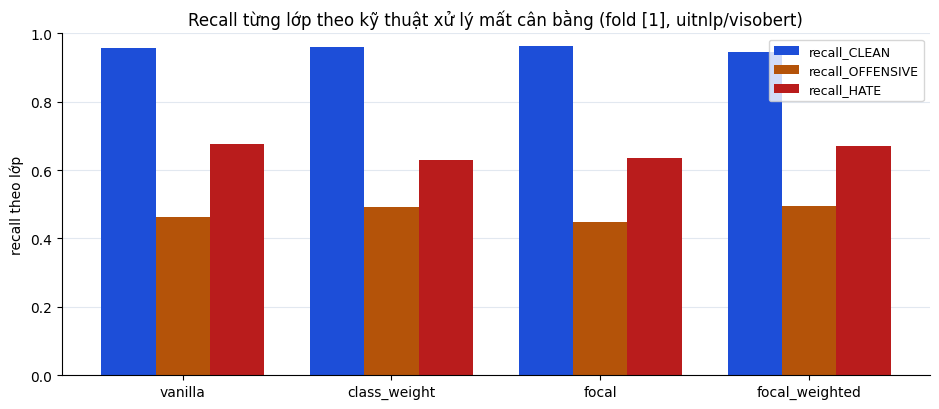

In [15]:
imbalance_rows = []
imbalance_model = {"model_name": FINAL_BACKBONE, "freeze_embeddings": False}
for technique in IMBALANCE_TECHNIQUES:
    out_dir = OUT_ROOT / f"imbalance_{technique}"
    started = time.perf_counter()
    _, fold_results = run_transformer_cv(
        imbalance_model,
        out_dir,
        trainer_factory=lambda train_labels, t=technique: build_trainer(t, train_labels),
        folds=IMBALANCE_FOLDS,
        run_name=f"imb_{technique}",
        collect_oof=False,
    )
    scalars = [r["scalars"] for r in fold_results]
    row = {
        "technique": technique,
        "macro_f1": round(fmean([s["macro_f1"] for s in scalars]), 4),
        "balanced_acc": round(fmean([s["balanced_accuracy"] for s in scalars]), 4),
        "recall_CLEAN": round(fmean([s["clean_recall"] for s in scalars]), 3),
        "recall_OFFENSIVE": round(fmean([s["offensive_recall"] for s in scalars]), 3),
        "recall_HATE": round(fmean([s["hate_recall"] for s in scalars]), 3),
    }
    imbalance_rows.append(row)
    print(f"{technique}: done in {time.perf_counter() - started:.1f}s -> {row}")

imbalance_table = pd.DataFrame(imbalance_rows).set_index("technique")
display(imbalance_table)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
x = np.arange(len(imbalance_rows))
width = 0.26
for offset, column, color in ((-width, "recall_CLEAN", "#1d4ed8"), (0.0, "recall_OFFENSIVE", "#b45309"), (width, "recall_HATE", "#b91c1c")):
    ax.bar(x + offset, imbalance_table[column], width, label=column, color=color)
ax.set_xticks(x, list(imbalance_table.index), fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel("recall theo lớp")
ax.set_title(f"Recall từng lớp theo kỹ thuật xử lý mất cân bằng (fold {list(IMBALANCE_FOLDS)}, {FINAL_BACKBONE})")
ax.legend(fontsize=9)
ax.grid(axis="y", color="#e2e8f0", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()
write_json(OUT_ROOT / "imbalance_ablation.json", {"folds": list(IMBALANCE_FOLDS), "rows": imbalance_rows})

### Part 4C — Learning-Rate Tuning

Rather than guessing a learning rate, we run a documented 3-step search protocol and keep the evidence (curves + grid results) so the choice is defensible, not arbitrary.


Map:   0%|          | 0/19238 [00:00<?, ? examples/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
5,1.112400
10,1.169800
15,1.141100
20,1.111500
25,1.118900
30,1.165000
35,1.114600
40,1.118400
45,1.094900
50,1.092500


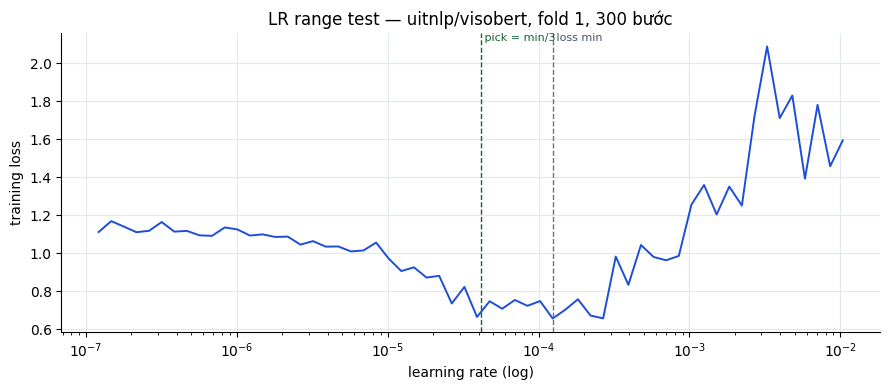

lr at min loss = 1.24e-04   pick (min/3) = 4.14e-05


In [16]:
from transformers import TrainerCallback


class LRRangeTest(TrainerCallback):
    # Exponential lr ramp; Trainer's scheduler is bypassed by writing lr straight into
    # the optimizer groups each step.
    def __init__(self, start, end, num_steps):
        self.start, self.end, self.n = start, end, num_steps

    def on_step_begin(self, args, state, control, optimizer=None, **kwargs):
        if state.global_step >= self.n:
            control.should_training_stop = True
            return
        frac = state.global_step / max(1, self.n - 1)
        lr = self.start * (self.end / self.start) ** frac
        for group in optimizer.param_groups:
            group["lr"] = lr


lr_search_config = {"model_name": FINAL_BACKBONE, "freeze_embeddings": False}
lr_tokenizer = load_tokenizer(FINAL_BACKBONE)
lr_collator = DataCollatorWithPadding(lr_tokenizer, pad_to_multiple_of=8)
lr_train_idx, _ = list(splitter.split(texts, labels))[LR_SEARCH_FOLD - 1]
lr_train_labels = [labels[i] for i in lr_train_idx]


def lr_tokenize(batch):
    return lr_tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)


lr_train_ds = Dataset.from_dict(
    {"text": [texts[i] for i in lr_train_idx], "label": lr_train_labels}
).map(lr_tokenize, batched=True, remove_columns=["text"])

lr_range_model = AutoModelForSequenceClassification.from_pretrained(FINAL_BACKBONE, num_labels=3)
lr_range_args = TrainingArguments(
    output_dir=str(OUT_ROOT / "lr_range_test"),
    logging_strategy="steps",
    logging_steps=5,
    save_strategy="no",
    eval_strategy="no",
    learning_rate=LR_RANGE_START,   # placeholder; the callback owns the schedule
    lr_scheduler_type="constant",
    warmup_ratio=0.0,
    per_device_train_batch_size=BATCH_SIZE,
    num_train_epochs=1.0,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to=[],
)
lr_range_trainer = build_trainer("class_weight", lr_train_labels)(
    model=lr_range_model,
    args=lr_range_args,
    train_dataset=lr_train_ds,
    data_collator=lr_collator,
    callbacks=[LRRangeTest(LR_RANGE_START, LR_RANGE_END, LR_RANGE_STEPS)],
)
lr_range_trainer.train()

LR_HIST = [(r["step"], r["loss"]) for r in lr_range_trainer.state.log_history if "loss" in r]
lr_steps = [step for step, _ in LR_HIST]
lr_losses = [loss for _, loss in LR_HIST]
lr_values = [
    LR_RANGE_START * (LR_RANGE_END / LR_RANGE_START) ** (step / max(1, LR_RANGE_STEPS - 1))
    for step in lr_steps
]
lr_at_min = lr_values[int(np.argmin(lr_losses))]
LR_RANGE_PICK = lr_at_min / 3.0

fig, ax = plt.subplots(figsize=(9.0, 4.0))
ax.plot(lr_values, lr_losses, color="#1d4ed8", linewidth=1.4)
ax.set_xscale("log")
ax.axvline(lr_at_min, color="#64748b", linestyle="--", linewidth=1)
ax.axvline(LR_RANGE_PICK, color="#166534", linestyle="--", linewidth=1)
ax.text(lr_at_min, ax.get_ylim()[1], " loss min", fontsize=8, color="#475569", va="top")
ax.text(LR_RANGE_PICK, ax.get_ylim()[1], " pick = min/3", fontsize=8, color="#166534", va="top")
ax.set_xlabel("learning rate (log)")
ax.set_ylabel("training loss")
ax.set_title(f"LR range test — {FINAL_BACKBONE}, fold {LR_SEARCH_FOLD}, {LR_RANGE_STEPS} bước")
ax.grid(color="#e2e8f0", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()
write_json(
    OUT_ROOT / "lr_range_test.json",
    {"steps": lr_steps, "lrs": lr_values, "losses": lr_losses,
     "lr_at_min": lr_at_min, "pick": LR_RANGE_PICK},
)
print(f"lr at min loss = {lr_at_min:.2e}   pick (min/3) = {LR_RANGE_PICK:.2e}")

Map:   0%|          | 0/19238 [00:00<?, ? examples/s]

Map:   0%|          | 0/4810 [00:00<?, ? examples/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.830300,0.629685,0.635464
2,0.524200,0.644217,0.680280
3,0.356700,0.735689,0.684459
4,0.231600,0.848464,0.691064
5,0.153800,1.054965,0.703661
6,0.113700,1.111713,0.702495


fold 1/5: macro_f1 0.7037
lr 1.0e-05: macro_f1 0.7037


...

Map:   0%|          | 0/4810 [00:00<?, ? examples/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.747300,0.577775,0.639487
2,0.429100,0.674355,0.678163
3,0.201500,1.020600,0.691613
4,0.113600,1.336611,0.696531
5,0.053800,1.735049,0.700966
6,0.034700,1.943176,0.702914


fold 1/5: macro_f1 0.7029
lr 5.0e-05: macro_f1 0.7029


,macro_f1,balanced_acc,recall_OFFENSIVE,recall_HATE,seconds
lr,,,,,
0.000010,0.7037,0.7214,0.508,0.726,125.6
0.000020,0.7109,0.7194,0.502,0.718,126.5
0.000030,0.7092,0.7086,0.495,0.687,127.1
0.000041,0.7083,0.7054,0.458,0.712,126.9
0.000050,0.7029,0.6783,0.430,0.644,126.5


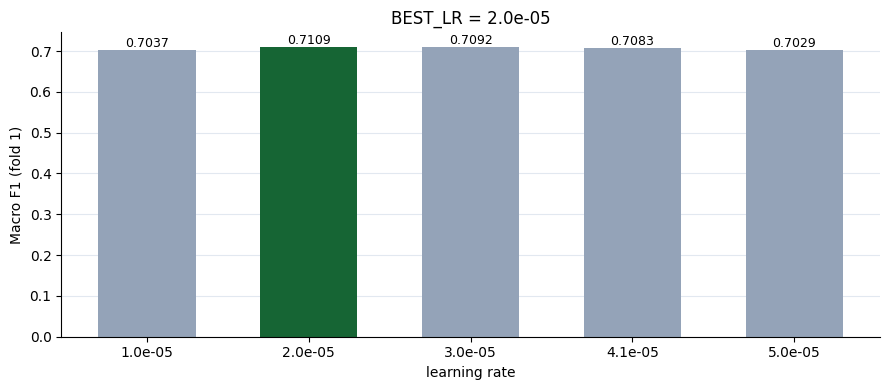

BEST_LR = 2.00e-05


In [17]:
LR_GRID_EFFECTIVE = tuple(sorted(set(LR_GRID) | {round(LR_RANGE_PICK, 8)}))
grid_rows = []
for lr_candidate in LR_GRID_EFFECTIVE:
    out_dir = OUT_ROOT / f"lr_grid_{lr_candidate:.0e}"
    started = time.perf_counter()
    _, fold_results = run_transformer_cv(
        lr_search_config,
        out_dir,
        folds=(LR_SEARCH_FOLD,),
        run_name=f"lr_{lr_candidate:.0e}",
        collect_oof=False,
        learning_rate=lr_candidate,
    )
    scalars = fold_results[0]["scalars"]
    grid_rows.append(
        {
            "lr": lr_candidate,
            "macro_f1": round(scalars["macro_f1"], 4),
            "balanced_acc": round(scalars["balanced_accuracy"], 4),
            "recall_OFFENSIVE": round(scalars["offensive_recall"], 3),
            "recall_HATE": round(scalars["hate_recall"], 3),
            "seconds": round(time.perf_counter() - started, 1),
        }
    )
    print(f"lr {lr_candidate:.1e}: macro_f1 {grid_rows[-1]['macro_f1']:.4f}")

grid_table = pd.DataFrame(grid_rows).set_index("lr")
display(grid_table)
BEST_LR = float(grid_table["macro_f1"].idxmax())

fig, ax = plt.subplots(figsize=(9.0, 4.0))
colors = ["#166534" if lr == BEST_LR else "#94a3b8" for lr in grid_table.index]
bars = ax.bar([f"{lr:.1e}" for lr in grid_table.index], grid_table["macro_f1"], color=colors, width=0.6)
for bar, value in zip(bars, grid_table["macro_f1"], strict=True):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("learning rate")
ax.set_ylabel(f"Macro F1 (fold {LR_SEARCH_FOLD})")
ax.set_title(f"BEST_LR = {BEST_LR:.1e}")
ax.grid(axis="y", color="#e2e8f0", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()
write_json(OUT_ROOT / "lr_grid.json", {"fold": LR_SEARCH_FOLD, "rows": grid_rows, "best_lr": BEST_LR})
print(f"BEST_LR = {BEST_LR:.2e}")

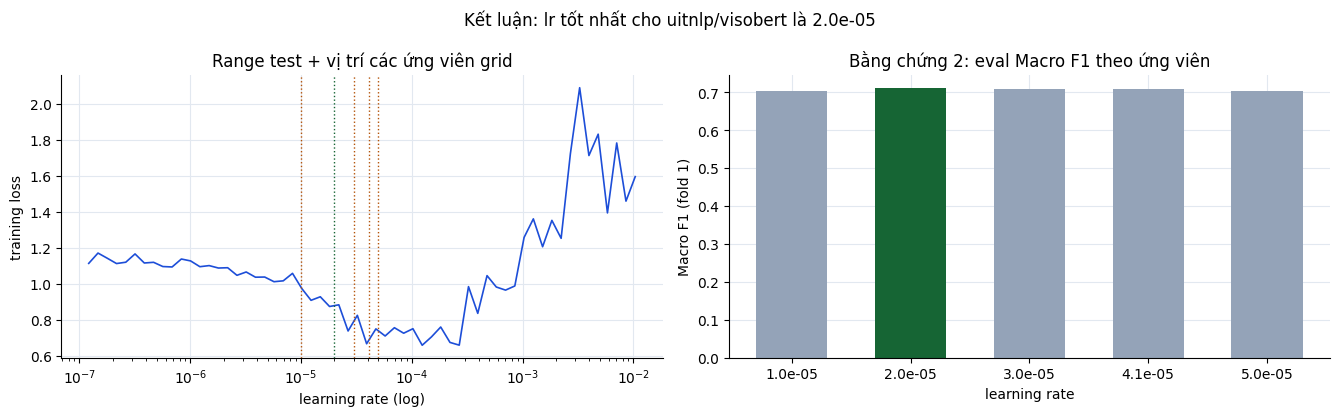

Stage 6 sẽ train với learning_rate = 2.00e-05


In [18]:
# Proof pack: range-test curve with the grid candidates marked, next to the grid result.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
axes[0].plot(lr_values, lr_losses, color="#1d4ed8", linewidth=1.2)
axes[0].set_xscale("log")
for lr_candidate in LR_GRID_EFFECTIVE:
    color = "#166534" if lr_candidate == BEST_LR else "#b45309"
    axes[0].axvline(lr_candidate, color=color, linestyle=":", linewidth=1)
axes[0].set_xlabel("learning rate (log)")
axes[0].set_ylabel("training loss")
axes[0].set_title("Range test + vị trí các ứng viên grid")
axes[1].bar([f"{lr:.1e}" for lr in grid_table.index], grid_table["macro_f1"],
            color=["#166534" if lr == BEST_LR else "#94a3b8" for lr in grid_table.index], width=0.6)
axes[1].set_xlabel("learning rate")
axes[1].set_ylabel(f"Macro F1 (fold {LR_SEARCH_FOLD})")
axes[1].set_title("Bằng chứng 2: eval Macro F1 theo ứng viên")
for ax in axes:
    ax.grid(color="#e2e8f0", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
fig.suptitle(f"Kết luận: lr tốt nhất cho {FINAL_BACKBONE} là {BEST_LR:.1e}", fontsize=12)
fig.tight_layout()
plt.show()

if LR_CV_CONFIRM:
    from scipy import stats

    confirm_name, confirm_results = run_transformer_cv(
        lr_search_config,
        OUT_ROOT / f"lr_confirm_{BEST_LR:.0e}",
        run_name=f"r2lr_{FINAL_BACKBONE.split('/')[-1]}",
        learning_rate=BEST_LR,
    )
    all_runs[confirm_name] = confirm_results
    reference = [r["scalars"]["macro_f1"] for r in all_runs["r2_" + FINAL_BACKBONE.split("/")[-1]]]
    observed = [r["scalars"]["macro_f1"] for r in confirm_results]
    deltas = [b - a for a, b in zip(reference, observed, strict=True)]
    print(
        pd.DataFrame(
            [
                {
                    "run": confirm_name,
                    "mean paired Δ macro_f1": round(fmean(deltas), 4),
                    "folds better": sum(d > 0 for d in deltas),
                    "paired t p": round(float(stats.ttest_rel(observed, reference).pvalue), 4),
                }
            ]
        ).set_index("run")
    )

FINAL_LEARNING_RATE = BEST_LR if USE_BEST_LR_IN_FINAL else LEARNING_RATE
print(f"Stage 6 sẽ train với learning_rate = {FINAL_LEARNING_RATE:.2e}")

## Part 5 — Comparing All Models So Far

We now pull every model's cross-validated results (classical baseline, each transformer backbone, each imbalance-handling variant) into one place, so we can see what's winning on Vietnamese `HATE`/`OFFENSIVE` detection before committing to a final model.

### Stage 4 — Output: summarize

In [19]:
summaries = {}
for run_name, fold_results in all_runs.items():
    summary = summarize_folds([result["scalars"] for result in fold_results])
    summaries[run_name] = summary
summary_table = pd.DataFrame(
    {
        run_name: {
            metric: f"{stats['mean']:.4f} ± {stats['std']:.4f}"
            for metric in HEADLINE_METRICS
            if (stats := summary.get(metric)) is not None
        }
        for run_name, summary in summaries.items()
    }
)
summary_table.index.name = "mean ± std over folds"
summary_table.fillna("n/a")

,classical_logreg,classical_svm,r2_phobert-base,r2_visobert,r2_xlm-roberta-base
mean ± std over folds,,,,,
macro_f1,0.6481 ± 0.0072,0.6525 ± 0.0080,0.6494 ± 0.0166,0.7115 ± 0.0039,0.6350 ± 0.0050
weighted_f1,0.8556 ± 0.0023,0.8679 ± 0.0025,0.8498 ± 0.0086,0.8869 ± 0.0035,0.8342 ± 0.0030
balanced_accuracy,0.6721 ± 0.0092,0.6271 ± 0.0103,0.7013 ± 0.0149,0.7144 ± 0.0245,0.7162 ± 0.0085
mcc,0.5391 ± 0.0082,0.5531 ± 0.0092,0.5379 ± 0.0219,0.6264 ± 0.0043,0.5221 ± 0.0065
roc_auc_ovr_weighted,0.9109 ± 0.0019,0.7733 ± 0.0076,0.9105 ± 0.0032,0.9387 ± 0.0047,0.9141 ± 0.0028
pr_auc_macro,0.6720 ± 0.0073,0.5170 ± 0.0067,0.6771 ± 0.0082,0.7421 ± 0.0127,0.6706 ± 0.0070


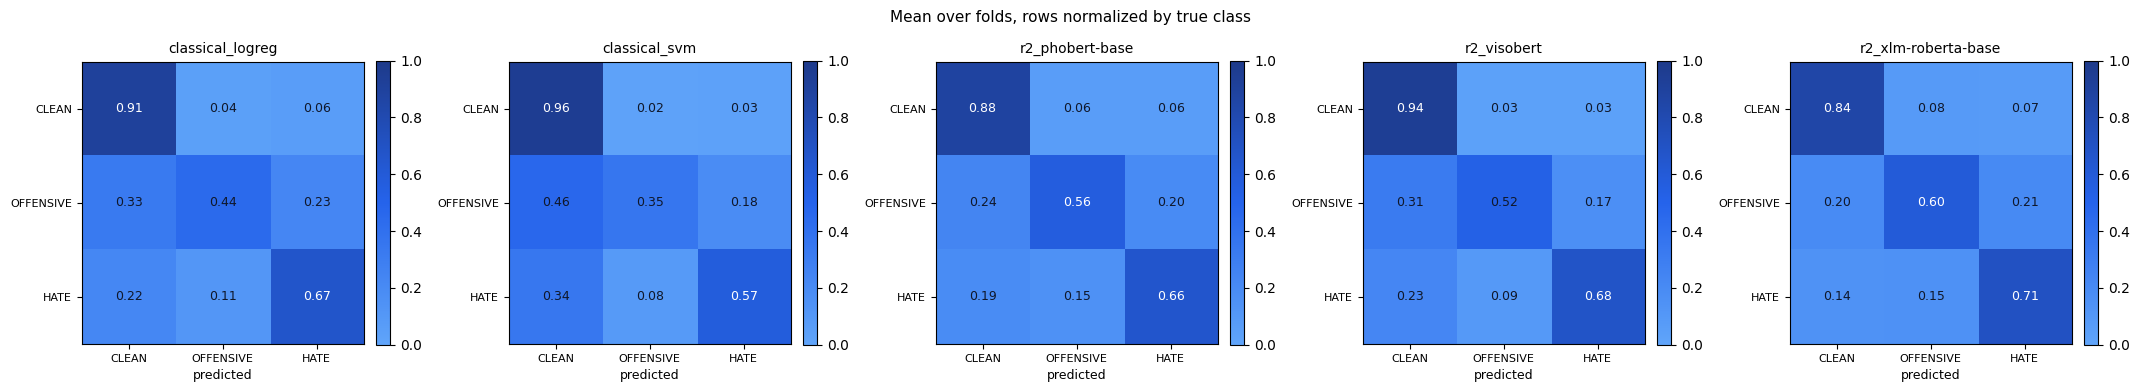

In [20]:
from matplotlib.colors import LinearSegmentedColormap

RAMP = LinearSegmentedColormap.from_list("vihsd_blues", ["#60a5fa", "#2563eb", "#1e3a8a"])


def mean_confusion(fold_results):
    return np.array([r["confusion_matrix"] for r in fold_results], dtype=float).mean(axis=0)


fig, axes = plt.subplots(1, len(all_runs), figsize=(4.3 * len(all_runs), 3.9), squeeze=False)
for ax, (run_name, fold_results) in zip(axes[0], all_runs.items(), strict=True):
    matrix = mean_confusion(fold_results)
    share = matrix / matrix.sum(axis=1, keepdims=True)
    image = ax.imshow(share, cmap=RAMP, vmin=0.0, vmax=1.0)
    ax.set_xticks(range(len(LABEL_NAMES)), LABEL_NAMES, fontsize=8)
    ax.set_yticks(range(len(LABEL_NAMES)), LABEL_NAMES, fontsize=8)
    ax.set_xlabel("predicted", fontsize=9)
    ax.set_title(run_name, fontsize=10)
    for row in range(len(LABEL_NAMES)):
        for col in range(len(LABEL_NAMES)):
            ax.text(
                col,
                row,
                f"{share[row, col]:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                color="white" if share[row, col] > 0.55 else "#0f172a",
            )
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Mean over folds, rows normalized by true class", fontsize=11)
fig.tight_layout()
plt.show()

## Part 6 — Ensemble & Safety-Oriented Threshold Calibration

Two refinements before we pick a winner:

1. **Ensemble** — combine classical + transformer predictions, since they tend to make different mistakes on Vietnamese text.
2. **Threshold calibration for `HATE`** — missing real hate speech is costlier than a false alarm, so we tune the decision threshold specifically for `HATE`-class recall, using only out-of-fold data (no leakage into the number we report).

### Stage 5 — Ensemble, hiệu chỉnh ngưỡng, rồi mới so sánh

Ba bước, tất cả leak-free nhờ OOF:

1. **Ensemble**: trung bình xác suất của các thành viên có xác suất thật (`ens_prob_avg`),
   và bỏ phiếu đa số có tie-break theo xác suất (`ens_vote`). Cả hai được biến thành
   `fold_results` nên vào thẳng leaderboard và kiểm định ghép cặp như mọi mô hình.
2. **Hiệu chỉnh ngưỡng cho lớp HATE**: giữ nguyên argmax, chỉ thêm luật
   "nếu `P(HATE) >= t` thì chẩn đoán HATE". `t` được chọn trên OOF của **các fold khác**
   (leave-one-fold-out) sao cho đạt `HATE_RECALL_TARGET`, rồi mới áp dụng lên fold giữ ra —
   không có chu trình nào vừa chọn vừa báo cáo trên cùng một mẫu.
3. **Leaderboard + kiểm định ghép cặp** giống run #1, giờ có thêm ensemble.

> **Does this change any trained model?** No — nothing here retrains anything; both steps
> work off out-of-fold predictions that already exist. `FINAL_BACKBONE` itself was already
> picked right after Part 4 (before Part 4B/4C spent any compute tuning it) — this section
> just re-confirms that pick still holds once the full leaderboard is in. What *does* flow
> forward from here is `t*`, the HATE-recall rule applied to the Part 7 test verdict and the
> Part 8 demo. Ensembling itself is diagnostic — the ensemble is scored here and again on the
> test set in Part 7, but only a single backbone can be shipped as `FINAL_BACKBONE`.

In [21]:
def build_ensemble(name, members, mode):
    probs, preds, kinds = [], [], []
    for member in members:
        store = OOF[member]
        assert (store["count"] == 1).all(), f"{member}: OOF coverage broken"
        probs.append(store["prob"])
        preds.append(store["pred"])
        kinds.append(store["prob_kind"])
    true, fold_of = store["true"], store["fold"]
    real = [p for p, kind in zip(probs, kinds, strict=True) if kind == "model"]
    avg = np.mean(real, axis=0)  # tie-break & reported probabilities use real probs only
    if mode == "prob":
        ens_pred = np.argmax(avg, axis=-1)
    else:
        stack = np.stack(preds, axis=1)
        ens_pred = np.empty(len(avg), dtype=int)
        for i in range(len(avg)):
            vote = np.bincount(stack[i], minlength=len(LABEL_NAMES))
            winners = np.flatnonzero(vote == vote.max())
            ens_pred[i] = int(winners[0]) if vote.max() >= 2 else int(np.argmax(avg[i]))
    out_dir = OUT_ROOT / name
    out_dir.mkdir(parents=True, exist_ok=True)
    ens_store = empty_oof(len(avg))
    ens_store["prob"] = avg
    ens_store["pred"] = ens_pred
    ens_store["true"] = true
    ens_store["fold"] = fold_of
    ens_store["count"] = np.ones(len(avg), dtype=int)
    ens_store["prob_kind"] = "model"
    OOF[name] = ens_store
    dump_oof(ens_store, out_dir, name)
    all_runs[name] = oof_fold_results(ens_store, out_dir, name)
    mean_macro = np.mean([r["scalars"]["macro_f1"] for r in all_runs[name]])
    print(f"{name} ({mode}): macro_f1 mean {mean_macro:.4f}")
    return name


build_ensemble("ens_prob_avg", ENSEMBLE_PROB_MEMBERS, "prob")
build_ensemble("ens_vote", ENSEMBLE_VOTE_MEMBERS, "vote")
for name in ("ens_prob_avg", "ens_vote"):
    summaries[name] = summarize_folds([r["scalars"] for r in all_runs[name]])

ens_prob_avg (prob): macro_f1 mean 0.7153
ens_vote (vote): macro_f1 mean 0.6845


In [22]:
CALIB_RUN = max(
    (n for n in all_runs if n.startswith("r2_")),
    key=lambda n: summaries[n]["macro_f1"]["mean"],
)

# Consistency check, not a (re)assignment: FINAL_BACKBONE was already picked right after
# Part 4 (see "Lock In the Backbone Before Tuning It Further"), specifically so Part 4B's
# imbalance ablation and Part 4C's learning-rate search would tune the real winner instead
# of a placeholder. This just confirms nothing upstream changed the leaderboard order since.
_BACKBONE_BY_RUN = {"r2_" + cfg["model_name"].split("/")[-1]: cfg["model_name"] for cfg in TRANSFORMER_MODELS}
assert FINAL_BACKBONE == _BACKBONE_BY_RUN[CALIB_RUN], (
    f"Leaderboard winner changed since Part 4 ({FINAL_BACKBONE} -> {_BACKBONE_BY_RUN[CALIB_RUN]}). "
    "Part 4B/4C tuned the wrong backbone — rerun them before trusting Part 7."
)
print(f"FINAL_BACKBONE confirmed: {FINAL_BACKBONE} (still the leaderboard winner; unchanged since Part 4)")

store = OOF[CALIB_RUN]
true_oof, prob_oof, fold_oof = store["true"], store["prob"], store["fold"]
HATE = 2


def apply_hate_rule(prob, t):
    pred = np.argmax(prob, axis=-1)
    return np.where(prob[:, HATE] >= t, HATE, pred)


def hate_recall_precision(y, pred):
    sel, truth = pred == HATE, y == HATE
    hit = float((sel & truth).sum())
    return hit / max(1, int(truth.sum())), hit / max(1, int(sel.sum()))


grid = np.round(np.arange(0.05, 0.55, 0.01), 3)
calib_rows = []
for k in range(1, FOLDS + 1):
    calib, held = fold_oof != k, fold_oof == k
    feasible = [
        t for t in grid if hate_recall_precision(true_oof[calib], apply_hate_rule(prob_oof[calib], t))[0] >= HATE_RECALL_TARGET
    ]
    t_star = max(feasible) if feasible else float(grid[0])
    base_pred = np.argmax(prob_oof[held], axis=-1)
    new_pred = apply_hate_rule(prob_oof[held], t_star)
    r0, p0 = hate_recall_precision(true_oof[held], base_pred)
    r1, p1 = hate_recall_precision(true_oof[held], new_pred)
    calib_rows.append(
        {
            "fold": k,
            "t*": round(t_star, 3),
            "HATE recall argmax": round(r0, 3),
            "HATE recall calibrated": round(r1, 3),
            "HATE precision argmax": round(p0, 3),
            "HATE precision calibrated": round(p1, 3),
            "Macro F1 argmax": round(float(f1_score(true_oof[held], base_pred, average="macro", zero_division=0)), 4),
            "Macro F1 calibrated": round(float(f1_score(true_oof[held], new_pred, average="macro", zero_division=0)), 4),
        }
    )
calib_table = pd.DataFrame(calib_rows).set_index("fold")
display(calib_table)
T_STAR = float(calib_table["t*"].mean())
print(f"calibrated on {CALIB_RUN}; mean t* = {T_STAR:.3f} (target HATE recall {HATE_RECALL_TARGET})")
write_json(OUT_ROOT / "threshold_calibration.json", {"run": CALIB_RUN, "target": HATE_RECALL_TARGET, "t_star_mean": T_STAR, "folds": calib_rows})

FINAL_BACKBONE confirmed: uitnlp/visobert (still the leaderboard winner; unchanged since Part 4)


,t*,HATE recall argmax,HATE recall calibrated,HATE precision argmax,HATE precision calibrated,Macro F1 argmax,Macro F1 calibrated
fold,,,,,,,
1,0.05,0.656,0.730,0.711,0.624,0.7091,0.7024
2,0.05,0.682,0.789,0.694,0.561,0.7146,0.6928
3,0.05,0.730,0.861,0.631,0.477,0.7107,0.6672
4,0.05,0.699,0.836,0.672,0.544,0.7169,0.6956
5,0.05,0.638,0.718,0.697,0.637,0.7060,0.7062


calibrated on r2_visobert; mean t* = 0.050 (target HATE recall 0.85)


### What Does the Threshold Actually Do?

`t*` is not a training choice — it only changes the decision rule applied to probabilities the
model already produced. The curve below sweeps every candidate threshold over the same
out-of-fold predictions used for calibration, so you can see the trade-off `t*` was picked
from: a lower threshold catches more real `HATE` comments (recall ↑) but also flags more
non-`HATE` comments by mistake (precision ↓). The Part 8 demo below lets you move this same
slider live on real predictions.

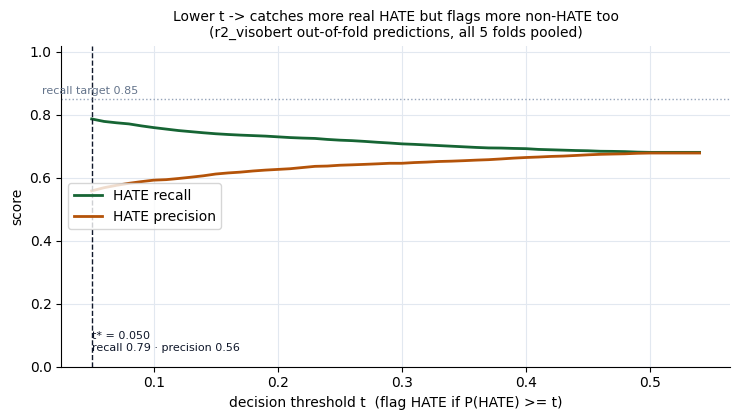

No threshold rule (plain argmax):  HATE recall 0.681, precision 0.679
With t* = 0.050:            HATE recall 0.787, precision 0.558  (target recall 0.85)


In [23]:
# Sweep the same OOF probabilities over every candidate threshold to show the
# recall/precision trade-off t* was chosen from (no retraining involved — just the rule).
sweep_rows = [
    {"t": t, "HATE recall": r, "HATE precision": p}
    for t in grid
    for r, p in [hate_recall_precision(true_oof, apply_hate_rule(prob_oof, t))]
]
sweep = pd.DataFrame(sweep_rows)
r_star, p_star = hate_recall_precision(true_oof, apply_hate_rule(prob_oof, T_STAR))
r_argmax, p_argmax = hate_recall_precision(true_oof, np.argmax(prob_oof, axis=-1))

fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.plot(sweep["t"], sweep["HATE recall"], label="HATE recall", color="#166534", linewidth=2)
ax.plot(sweep["t"], sweep["HATE precision"], label="HATE precision", color="#b45309", linewidth=2)
ax.axvline(T_STAR, color="#0f172a", linestyle="--", linewidth=1)
ax.annotate(f"t* = {T_STAR:.3f}\nrecall {r_star:.2f} · precision {p_star:.2f}",
            xy=(T_STAR, 0.05), fontsize=8, color="#0f172a")
ax.axhline(HATE_RECALL_TARGET, color="#94a3b8", linestyle=":", linewidth=1)
ax.text(0.01, HATE_RECALL_TARGET + 0.015, f"recall target {HATE_RECALL_TARGET:.2f}", fontsize=8, color="#64748b")
ax.set_xlabel("decision threshold t  (flag HATE if P(HATE) >= t)")
ax.set_ylabel("score")
ax.set_ylim(0, 1.02)
ax.set_title(
    "Lower t -> catches more real HATE but flags more non-HATE too\n"
    f"({CALIB_RUN} out-of-fold predictions, all {FOLDS} folds pooled)",
    fontsize=10,
)
ax.legend(loc="center left")
ax.grid(color="#e2e8f0", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

print(f"No threshold rule (plain argmax):  HATE recall {r_argmax:.3f}, precision {p_argmax:.3f}")
print(f"With t* = {T_STAR:.3f}:            HATE recall {r_star:.3f}, precision {p_star:.3f}  (target recall {HATE_RECALL_TARGET:.2f})")

In [24]:
leaderboard = pd.DataFrame(
    {
        run_name: {metric: summary[metric]["mean"] for metric in HEADLINE_METRICS if metric in summary}
        for run_name, summary in summaries.items()
    }
).T.sort_values("macro_f1", ascending=False)
leaderboard.insert(0, "rank", range(1, len(leaderboard) + 1))
print("Leaderboard — Macro F1 decides the ranking; the rest is diagnostic.")
leaderboard.round(4).fillna("n/a")

Leaderboard — Macro F1 decides the ranking; the rest is diagnostic.


,rank,macro_f1,weighted_f1,balanced_accuracy,mcc,roc_auc_ovr_weighted,pr_auc_macro
ens_prob_avg,1,0.7153,0.8889,0.7166,0.6328,0.9336,0.7296
r2_visobert,2,0.7115,0.8869,0.7144,0.6264,0.9387,0.7421
ens_vote,3,0.6845,0.8778,0.6751,0.5920,0.9336,0.7296
classical_svm,4,0.6525,0.8679,0.6271,0.5531,0.7733,0.5170
r2_phobert-base,5,0.6494,0.8498,0.7013,0.5379,0.9105,0.6771
classical_logreg,6,0.6481,0.8556,0.6721,0.5391,0.9109,0.6720
r2_xlm-roberta-base,7,0.6350,0.8342,0.7162,0.5221,0.9141,0.6706


In [25]:
from scipy import stats

REFERENCE_MODEL = "classical_logreg"   # the project's accepted baseline (HYPE-4)
reference = [r["scalars"]["macro_f1"] for r in all_runs[REFERENCE_MODEL]]

paired_rows = []
for run_name, fold_results in all_runs.items():
    if run_name == REFERENCE_MODEL:
        continue
    observed = [r["scalars"]["macro_f1"] for r in fold_results]
    deltas = [b - a for a, b in zip(reference, observed, strict=True)]
    paired_rows.append(
        {
            "model": run_name,
            "mean paired Δ macro_f1": round(fmean(deltas), 4),
            "folds better": sum(d > 0 for d in deltas),
            "paired t p": round(float(stats.ttest_rel(observed, reference).pvalue), 4),
            "wilcoxon p": round(float(stats.wilcoxon(observed, reference).pvalue), 4),
        }
    )
print(f"Paired against {REFERENCE_MODEL} over the {FOLDS} shared folds:")
display(pd.DataFrame(paired_rows).set_index("model"))

Paired against classical_logreg over the 5 shared folds:


,mean paired Δ macro_f1,folds better,paired t p,wilcoxon p
model,,,,
classical_svm,0.0044,3,0.2761,0.3125
r2_phobert-base,0.0012,3,0.8863,1.0000
r2_visobert,0.0633,5,0.0001,0.0625
r2_xlm-roberta-base,-0.0131,0,0.0332,0.0625
ens_prob_avg,0.0671,5,0.0000,0.0625
ens_vote,0.0363,5,0.0000,0.0625


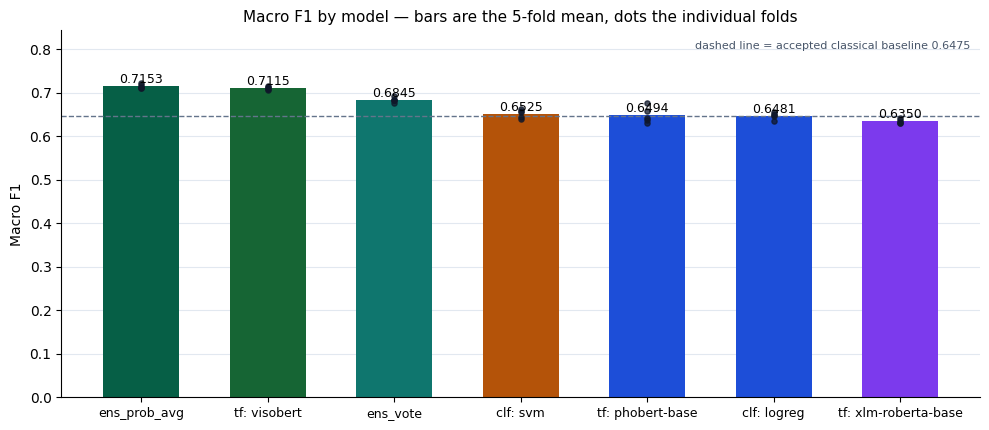

In [26]:
MODEL_COLORS = {
    "classical_logreg": "#1d4ed8",
    "classical_svm": "#b45309",
    "r2_visobert": "#166534",
    "r2_xlm-roberta-base": "#7c3aed",
    "ens_prob_avg": "#065f46",
    "ens_vote": "#0f766e",
}
names = list(leaderboard.index)
means = [summaries[name]["macro_f1"]["mean"] for name in names]

fig, ax = plt.subplots(figsize=(10, 4.4))
xs = list(range(len(names)))
bars = ax.bar(xs, means, color=[MODEL_COLORS.get(name, "#1d4ed8") for name in names], width=0.6)
for x, name in zip(xs, names, strict=True):
    ax.scatter([x] * FOLDS, [r["scalars"]["macro_f1"] for r in all_runs[name]], color="#0f172a", s=14, zorder=3, alpha=0.75)
for bar, mean in zip(bars, means, strict=True):
    ax.text(bar.get_x() + bar.get_width() / 2, mean, f"{mean:.4f}", ha="center", va="bottom", fontsize=9)
ax.axhline(0.6475, color="#64748b", linestyle="--", linewidth=1)
ax.text(0.99, 0.97, "dashed line = accepted classical baseline 0.6475", transform=ax.transAxes, ha="right", va="top", fontsize=8, color="#475569")
ax.set_xticks(xs, [n.replace("r2_", "tf: ").replace("classical_", "clf: ") for n in names], fontsize=9)
ax.set_ylabel("Macro F1")
ax.set_ylim(0, max(means) * 1.18)
ax.set_title("Macro F1 by model — bars are the 5-fold mean, dots the individual folds", fontsize=11)
ax.grid(axis="y", color="#e2e8f0", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

## Part 7 — Final Model: Official Test-Set Results

**This is the number that matters for a go/no-go decision.** One model, trained on the full Vietnamese training set, model-selected on the validation set, and evaluated exactly once on the held-out official test set (6,680 Vietnamese comments untouched anywhere else in this notebook).



In [27]:
val_ds = load_dataset("uitnlp/vihsd", split="validation")
test_ds_official = load_dataset("uitnlp/vihsd", split="test")


def split_xy(ds):
    tc = next(c for c in ("free_text", "text", "comment") if c in ds.column_names)
    lc = next(c for c in ("label_id", "label") if c in ds.column_names)
    return [str(row[tc]) for row in ds], [normalize_label(row[lc]) for row in ds]


val_texts, val_labels = split_xy(val_ds)
test_texts, test_labels = split_xy(test_ds_official)
print(f"validation {len(val_texts):,} · test {len(test_texts):,} examples")

validation 2,672 · test 6,680 examples


In [28]:
final_dir = OUT_ROOT / "final"
final_dir.mkdir(parents=True, exist_ok=True)
final_tokenizer = load_tokenizer(FINAL_BACKBONE)
final_collator = DataCollatorWithPadding(final_tokenizer, pad_to_multiple_of=8)


def tokenize_final(batch):
    return final_tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)


train_full = Dataset.from_dict({"text": texts, "label": labels}).map(tokenize_final, batched=True, remove_columns=["text"])
val_tok = Dataset.from_dict({"text": val_texts, "label": val_labels}).map(tokenize_final, batched=True, remove_columns=["text"])
test_tok = Dataset.from_dict({"text": test_texts, "label": test_labels}).map(tokenize_final, batched=True, remove_columns=["text"])

final_model = AutoModelForSequenceClassification.from_pretrained(FINAL_BACKBONE, num_labels=3)
final_args = TrainingArguments(
    output_dir=str(final_dir),
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=1,
    learning_rate=globals().get("FINAL_LEARNING_RATE", LEARNING_RATE),
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=256,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    num_train_epochs=EPOCHS,
    lr_scheduler_type="linear",
    warmup_ratio=WARMUP_RATIO,
    optim=OPTIM,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to=[],
)
final_trainer = weighted_loss_trainer_class(class_weights(labels))(
    model=final_model,
    args=final_args,
    train_dataset=train_full,
    eval_dataset=val_tok,
    data_collator=final_collator,
    compute_metrics=macro_f1_metric,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)
final_trainer.train()
# Trainer persists weights via save_model(); save_pretrained() lives on model/tokenizer objects.
final_trainer.save_model(str(final_dir / "model"))
final_tokenizer.save_pretrained(str(final_dir / "model"))

final_output = final_trainer.predict(test_tok)
final_prob = torch.softmax(torch.tensor(final_output.predictions), dim=-1).numpy()
final_pred = np.argmax(final_prob, axis=-1)
final_report = evaluate_fold("test", test_labels, final_pred, final_prob, final_dir)
print(f"FINAL {FINAL_BACKBONE} on official test: macro_f1 {final_report['scalars']['macro_f1']:.4f}")

Map:   0%|          | 0/24048 [00:00<?, ? examples/s]

Map:   0%|          | 0/2672 [00:00<?, ? examples/s]

Map:   0%|          | 0/6680 [00:00<?, ? examples/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.757800,0.609713,0.687794
2,0.453300,0.641115,0.706363
3,0.245000,0.931879,0.717894
4,0.131300,1.424473,0.717263
5,0.078900,1.564873,0.712913


FINAL uitnlp/visobert on official test: macro_f1 0.6834


In [29]:
final_classical = {}
for model in CLASSICAL_MODELS:
    pipeline = build_classical_pipeline(model, SEED).fit(texts, labels)
    pred = pipeline.predict(test_texts)
    prob = pipeline.predict_proba(test_texts) if hasattr(pipeline, "predict_proba") else None
    final_classical[model] = (pred, prob)

test_rows = [{"model": FINAL_BACKBONE, "macro_f1": round(final_report["scalars"]["macro_f1"], 4),
              "hate_recall": round(final_report["scalars"]["hate_recall"], 4),
              "offensive_recall": round(final_report["scalars"]["offensive_recall"], 4)}]
for model, (pred, prob) in final_classical.items():
    rep = evaluate_fold("test", test_labels, pred, prob, final_dir)
    test_rows.append({"model": f"classical_{model}", "macro_f1": round(rep["scalars"]["macro_f1"], 4),
                      "hate_recall": round(rep["scalars"]["hate_recall"], 4),
                      "offensive_recall": round(rep["scalars"]["offensive_recall"], 4)})

# HATE-calibrated version of the SAME final model, using Part 6's t* — shows what the
# calibration actually buys on the official test set (recall up, at some precision cost).
final_pred_calibrated = apply_hate_rule(final_prob, T_STAR)
final_report_calibrated = evaluate_fold("test", test_labels, final_pred_calibrated, final_prob, final_dir)
test_rows.append({"model": f"{FINAL_BACKBONE} (HATE-calibrated, t*={T_STAR:.3f})",
                  "macro_f1": round(final_report_calibrated["scalars"]["macro_f1"], 4),
                  "hate_recall": round(final_report_calibrated["scalars"]["hate_recall"], 4),
                  "offensive_recall": round(final_report_calibrated["scalars"]["offensive_recall"], 4)})

# Ensemble on the official test set too (Part 6 only scored this via cross-validated OOF) —
# re-enabled so the ensemble's real effect, if any, shows up next to the final verdict.
avg_test = np.mean([final_prob] + [prob for _, prob in final_classical.values() if prob is not None], axis=0)
ens_test_pred = np.argmax(avg_test, axis=-1)
ens_report = evaluate_fold("test", test_labels, ens_test_pred, avg_test, final_dir)
test_rows.append({"model": "ensemble_prob_avg", "macro_f1": round(ens_report["scalars"]["macro_f1"], 4),
                  "hate_recall": round(ens_report["scalars"]["hate_recall"], 4),
                  "offensive_recall": round(ens_report["scalars"]["offensive_recall"], 4)})

PUBLISHED_MACRO_F1 = {
    FINAL_BACKBONE: "0.6771 (ViSoBERT, SOTA)",
    "xlm-roberta-base": "0.6550 (XLM-R base)",
    "classical_logreg": "0.52-0.56 (classical TF-IDF)",
    "classical_svm": "0.52-0.56 (classical TF-IDF)",
}
BEATS_CLASSICAL_GATE, SOTA_GATE = 0.67, 0.68
verdict = pd.DataFrame(test_rows)
verdict["published reference"] = [PUBLISHED_MACRO_F1.get(m, "n/a") for m in verdict["model"]]
verdict["beats classical (>=0.67)"] = ["yes" if m >= BEATS_CLASSICAL_GATE else "no" for m in verdict["macro_f1"]]
verdict["SOTA-level (>=0.68)"] = ["yes" if m >= SOTA_GATE else "no" for m in verdict["macro_f1"]]
display(verdict.set_index("model"))
write_json(final_dir / "test_report.json", {"rows": test_rows, "scalars": final_report["scalars"]})

,macro_f1,hate_recall,offensive_recall,published reference,beats classical (>=0.67),SOTA-level (>=0.68)
model,,,,,,
uitnlp/visobert,0.6834,0.7384,0.5068,"0.6771 (ViSoBERT, SOTA)",yes,yes
classical_logreg,0.6439,0.6701,0.4437,0.52-0.56 (classical TF-IDF),no,no
classical_svm,0.6276,0.5436,0.3086,0.52-0.56 (classical TF-IDF),no,no
"uitnlp/visobert (HATE-calibrated, t*=0.050)",0.6413,0.8895,0.3941,n/a,no,no
ensemble_prob_avg,0.6890,0.7456,0.4910,n/a,yes,yes


### Part 7B — Persist the Model (so the demo never needs a retrain)

Part 7 saved weights to `OUT_ROOT/final/model`. That is **session-local disk**: on Colab or Kaggle it
disappears the moment the session ends. Part 8 also used to need the live `final_trainer` object, which
is why reaching the demo meant re-running everything above it.

This cell repackages what Part 7 already produced into one durable, self-describing **demo bundle**:

| | |
|---|---|
| `model/` | weights + tokenizer, exactly as `save_pretrained()` wrote them |
| `demo_config.json` | label order, `max_length`, the calibrated `t*`, training recipe, test metrics |
| `README.md` | model card — this is what the Hub renders if you publish |

Nothing here trains. It copies, records, **reloads the copy to prove the artifact actually works**, zips
it, and optionally pushes it to a Hugging Face model repo. Part 8 — or `uv run vihate demo` on any other
machine — then starts from that bundle in about a minute.

> The calibrated threshold travels *inside* the bundle. `t*` costs ~1 hour of cross-validation to
> compute in Part 6, so persisting it is precisely what makes a training-free demo possible.


In [ ]:
# --- Part 7B: persist the final model. Nothing here trains; it repackages Part 7's output. ---
# The read side of this contract is src/vihate/demo_bundle.py (load_demo_config / resolve_bundle).
import shutil
from datetime import datetime, timezone

MODEL_SRC = final_dir / "model"
assert (MODEL_SRC / "config.json").is_file(), (
    f"{MODEL_SRC} is not a save_pretrained() output — run Part 7 first"
)

demo_config = {
    "schema_version": DEMO_SCHEMA_VERSION,
    "task": "vihsd-3way",
    "labels": list(LABEL_NAMES),
    "hate_label_index": len(LABEL_NAMES) - 1,
    "backbone": FINAL_BACKBONE,
    "max_length": int(MAX_LENGTH),
    "threshold": {
        "t_star": float(T_STAR),
        "hate_recall_target": float(HATE_RECALL_TARGET),
        "calibrated_on": CALIB_RUN,
    },
    "training": {
        "learning_rate": float(globals().get("FINAL_LEARNING_RATE", LEARNING_RATE)),
        "best_lr": globals().get("BEST_LR"),
        "epochs_budget": EPOCHS,
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "folds": FOLDS,
    },
    "metrics": {
        "test_macro_f1": round(final_report["scalars"]["macro_f1"], 4),
        "test_macro_f1_hate_calibrated": round(final_report_calibrated["scalars"]["macro_f1"], 4),
        "test_hate_recall": round(final_report["scalars"]["hate_recall"], 4),
        "test_offensive_recall": round(final_report["scalars"]["offensive_recall"], 4),
    },
    "has_sample": False,
    "created_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
}

if BUNDLE_DIR.exists():
    shutil.rmtree(BUNDLE_DIR)
BUNDLE_DIR.mkdir(parents=True)
shutil.copytree(MODEL_SRC, BUNDLE_DIR / "model")
write_json(BUNDLE_DIR / "demo_config.json", demo_config)
(BUNDLE_DIR / "README.md").write_text(
    f"""---
license: other
library_name: transformers
pipeline_tag: text-classification
base_model: {FINAL_BACKBONE}
tags:
- vietnamese
- hate-speech-detection
- content-moderation
datasets:
- uitnlp/vihsd
---

# ViHSD — Vietnamese Hate-Speech Detection (3-way)

Fine-tuned `{FINAL_BACKBONE}` classifying Vietnamese social-media comments as
`{'` / `'.join(LABEL_NAMES)}` on [`uitnlp/vihsd`](https://huggingface.co/datasets/uitnlp/vihsd).

**Content warning:** this model exists to *detect* hateful Vietnamese text. Its inputs and outputs
quote real user-generated content, including slurs. Nothing here endorses the training labels.

## Decision threshold

`HATE` is not decided by argmax alone — a comment is escalated for moderation review when
`P(HATE) >= t*`, with a calibrated **`t*` = {T_STAR:.3f}** for a HATE recall target of
{HATE_RECALL_TARGET} on `{CALIB_RUN}`. Recall-biased on purpose: a missed hateful comment costs
more than an extra item in the review queue.

## Official test split (6,680 comments)

| metric | value |
|---|---|
| macro F1 (argmax) | {demo_config['metrics']['test_macro_f1']} |
| macro F1 (HATE-calibrated) | {demo_config['metrics']['test_macro_f1_hate_calibrated']} |
| HATE recall | {demo_config['metrics']['test_hate_recall']} |
| OFFENSIVE recall | {demo_config['metrics']['test_offensive_recall']} |

`demo_config.json` is the source of truth for label order, `max_length` and `t*`. Read the threshold
from there rather than hard-coding it, so a deployed demo cannot drift from this notebook.
""",
    encoding="utf-8",
)

# Prove the artifact works before the session dies: reload the copy, not the in-memory model.
_probe_tokenizer = load_tokenizer(str(BUNDLE_DIR / "model"))
_probe_model = AutoModelForSequenceClassification.from_pretrained(str(BUNDLE_DIR / "model")).eval()
_probe_inputs = _probe_tokenizer(
    "Hôm nay thời tiết đẹp", truncation=True, max_length=MAX_LENGTH, return_tensors="pt"
)
with torch.inference_mode():
    _probe_probs = torch.softmax(_probe_model(**_probe_inputs).logits, dim=-1)[0]
assert tuple(_probe_probs.shape) == (len(LABEL_NAMES),), f"unexpected head shape {tuple(_probe_probs.shape)}"
print(f"self-check OK — reloaded {BUNDLE_DIR / 'model'}; probabilities sum to {float(_probe_probs.sum()):.4f}")
del _probe_model, _probe_tokenizer, _probe_inputs, _probe_probs

BUNDLE_ZIP = Path(
    shutil.make_archive(str(OUT_ROOT / "vihsd_demo_bundle"), "zip", root_dir=str(OUT_ROOT), base_dir=BUNDLE_DIR.name)
)
_bundle_mb = sum(p.stat().st_size for p in BUNDLE_DIR.rglob("*") if p.is_file()) / 1e6
print(f"bundle : {BUNDLE_DIR} ({_bundle_mb:.0f} MB)")
print(f"zip    : {BUNDLE_ZIP} ({BUNDLE_ZIP.stat().st_size / 1e6:.0f} MB) — download this, or copy it to Drive")

if HF_MODEL_REPO:
    from huggingface_hub import HfApi

    _api = HfApi()
    _api.create_repo(HF_MODEL_REPO, repo_type="model", exist_ok=True, private=HF_REPO_PRIVATE)
    HF_MODEL_URL = _api.upload_folder(
        folder_path=str(BUNDLE_DIR), repo_id=HF_MODEL_REPO, ignore_patterns=["*.zip"]
    )
    DEMO_SOURCE = DEMO_SOURCE or HF_MODEL_REPO
    print(f"hub    : {HF_MODEL_URL}")
else:
    print("hub    : skipped — set HF_MODEL_REPO in the config cell to publish (needs a write token)")

print("\nStart the demo from this bundle, with no training:")
print(f"  notebook : run the config cell + Part 8 only (DEMO_SOURCE = {DEMO_SOURCE or str(BUNDLE_DIR)!r})")
print(f"  anywhere : uv run vihate demo --model {HF_MODEL_REPO or str(BUNDLE_DIR)}")
print("  permanent URL (once, from a repo checkout — a Colab share link expires in 7 days):")
print(
    f"    uv run vihate publish-space --space <your-hf-user>/vihsd-demo "
    f"--model {HF_MODEL_REPO or '<your-hf-user>/vihsd-visobert'}"
)

## Part 8 — Live Demo: Try It on Vietnamese Text

Type or paste any Vietnamese comment below. The demo runs the final model plus the calibrated `HATE` threshold from Part 6, so it flags content for moderation review the same way the production model would.

Two ways to use it: a **single-comment** box for quick spot checks, and a **batch file** tab for
running a whole test set at once (`.txt`, one Vietnamese comment per line, or `.csv`/`.tsv` with a
text column) — output comes back as one table with the prediction and class probabilities per row,
same information as the single-comment view, downloadable as CSV.

**No retraining required.** Part 8 loads the bundle that Part 7B persisted. In a fresh session — a new
Colab tab, a laptop, a Hugging Face Space — run only the **config cell** and **Part 8** and the demo is
up in about a minute, because the weights *and* the calibrated `t*` are read from `demo_config.json`
instead of being recomputed. Point `DEMO_SOURCE` at a Hub repo id to serve a published model instead of
the local bundle.

Both tabs expose the decision threshold as a slider (starting at the calibrated `t*` from Part 6) — drag it to see the recall/precision trade-off for yourself on live predictions, the same trade-off charted just above. A ready-made sample file for the batch tab is generated right before the demo launches, so there's something to upload immediately.


In [30]:
# Part 8 runs in a cold session: these imports are what let it work without Parts 1-7 above.
import json

import pandas as pd
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def load_demo_tokenizer(path):
    # Slow tokenizer first, same reason Part 4 does it: the fast PhoBERT/XLM-R path is
    # why the project pins transformers<5.
    try:
        return AutoTokenizer.from_pretrained(path, use_fast=False)
    except (ValueError, OSError, ImportError):
        return AutoTokenizer.from_pretrained(path, use_fast=True)


if "final_trainer" in globals():
    # Same session as Part 7 — reuse the in-memory model, nothing to reload.
    demo_model = final_trainer.model.to(device)
    demo_tokenizer = final_tokenizer
    DEMO_LABEL_NAMES = list(LABEL_NAMES)
    DEMO_MAX_LENGTH = int(MAX_LENGTH)
    DEMO_T_STAR = float(T_STAR)
    DEMO_ORIGIN = "live training state (Part 7 ran in this session)"
else:
    # Cold start — load the bundle Part 7B persisted. One model download, zero training.
    _source = DEMO_SOURCE or BUNDLE_DIR
    _path = Path(_source).expanduser()
    if _path.is_dir():
        _bundle = _path
    else:
        from huggingface_hub import snapshot_download

        _bundle = Path(
            snapshot_download(repo_id=str(_source), allow_patterns=["model/*", "demo_config.json"])
        )
    _config = json.loads((_bundle / "demo_config.json").read_text(encoding="utf-8"))
    assert _config["schema_version"] == DEMO_SCHEMA_VERSION, (
        f"bundle is schema_version {_config['schema_version']!r}; "
        f"this notebook reads {DEMO_SCHEMA_VERSION}"
    )
    demo_tokenizer = load_demo_tokenizer(str(_bundle / "model"))
    demo_model = AutoModelForSequenceClassification.from_pretrained(str(_bundle / "model")).to(device)
    DEMO_LABEL_NAMES = list(_config["labels"])
    DEMO_MAX_LENGTH = int(_config["max_length"])
    DEMO_T_STAR = float(_config["threshold"]["t_star"])
    DEMO_ORIGIN = f"persisted bundle ({_bundle})"

demo_model.eval()
LABELS = {index: name for index, name in enumerate(DEMO_LABEL_NAMES)}
HATE_LABEL = DEMO_LABEL_NAMES[-1]
print(f"demo model ready from {DEMO_ORIGIN}")
print(f"labels {DEMO_LABEL_NAMES} · max_length {DEMO_MAX_LENGTH} · calibrated t* {DEMO_T_STAR:.3f}")

# In a full run the batch-tab sample is generated just below; a cold start has no sample file.
SAMPLE_NOTE = (
    f"No file handy? A ready-made sample is already saved at `{demo_test_path}` "
    "(generated above) — upload that to try this tab right away."
    if "demo_test_path" in globals()
    else "No file handy? Any `.txt` (one Vietnamese comment per line) or `.csv`/`.tsv` with a "
    "`free_text`, `text` or `comment` column works."
)


def predict_detailed(text, threshold=None):
    # threshold=None -> use the calibrated t* that travelled in the bundle; pass a number to test another cutoff.
    threshold = DEMO_T_STAR if threshold is None else float(threshold)
    text = (text or "").strip()
    if not text:
        return "Please enter some text.", {}
    inputs = demo_tokenizer(text, truncation=True, max_length=DEMO_MAX_LENGTH, return_tensors="pt").to(device)
    with torch.inference_mode():
        logits = demo_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)[0].cpu()
    scores = {LABELS[i]: float(probs[i]) for i in range(len(probs))}
    prediction = LABELS[int(torch.argmax(probs))]
    if float(probs[len(DEMO_LABEL_NAMES) - 1]) >= threshold:
        prediction += f" (ưu tiên kiểm duyệt: P({HATE_LABEL}) >= {threshold:.3f})"
    return prediction, scores


def _read_texts_from_file(file_path):
    """Load test comments from an uploaded .txt (one per line) or .csv/.tsv file."""
    path = Path(file_path)
    if path.suffix.lower() in (".csv", ".tsv"):
        sep = "\t" if path.suffix.lower() == ".tsv" else ","
        table = pd.read_csv(path, sep=sep)
        text_col = next((c for c in ("free_text", "text", "comment") if c in table.columns), table.columns[0])
        return [str(value) for value in table[text_col].tolist()]
    return [line.strip() for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]


def predict_batch(file, threshold=None):
    """Batch version of predict_detailed: many Vietnamese comments in, one prediction table out."""
    columns = ["text", "predicted_class", "P(CLEAN)", "P(OFFENSIVE)", "P(HATE)", "flagged_for_review"]
    if file is None:
        return pd.DataFrame(columns=columns), None
    # str/Path first: a Path also has a `.name`, and taking it would silently
    # resolve to a bare filename in the current directory.
    file_path = Path(file) if isinstance(file, (str, Path)) else Path(file.name)
    rows = []
    for text in _read_texts_from_file(file_path):
        prediction, scores = predict_detailed(text, threshold)
        rows.append(
            {
                "text": text,
                "predicted_class": prediction.split(" (")[0],
                "P(CLEAN)": round(scores.get("CLEAN", 0.0), 4),
                "P(OFFENSIVE)": round(scores.get("OFFENSIVE", 0.0), 4),
                "P(HATE)": round(scores.get("HATE", 0.0), 4),
                "flagged_for_review": "ưu tiên kiểm duyệt" in prediction,
            }
        )
    result_table = pd.DataFrame(rows, columns=columns)
    out_path = OUT_ROOT / "demo_batch_predictions.csv"
    result_table.to_csv(out_path, index=False, encoding="utf-8-sig")
    return result_table, str(out_path)

### A Ready-Made Test File for the Batch Tab

A small sample, drawn from the **validation split** (never the official test split, which
stays untouched everywhere in this notebook) so it can be regenerated freely. Raw comment
text is written straight to the CSV and never printed in this notebook, matching the
content-handling convention used everywhere else here.

In [31]:
# --- Sample file for the "Batch file" tab below: a few real, already-published, already-
# labeled comments per class from the validation split (not the held-out test split). ---
DEMO_SAMPLE_PER_CLASS = 5
rng = np.random.default_rng(SEED)
val_labels_arr = np.array(val_labels)
demo_rows = []
for class_id, class_name in LABELS.items():
    class_idx = np.flatnonzero(val_labels_arr == class_id)
    picked = rng.choice(class_idx, size=min(DEMO_SAMPLE_PER_CLASS, len(class_idx)), replace=False)
    demo_rows.extend({"text": val_texts[i], "true_label": class_name} for i in picked)
rng.shuffle(demo_rows)

demo_test_set = pd.DataFrame(demo_rows, columns=["text", "true_label"])
demo_test_path = OUT_ROOT / "demo_test_set.csv"
demo_test_set.to_csv(demo_test_path, index=False, encoding="utf-8-sig")
print(f"Wrote {len(demo_test_set)} sample comments ({DEMO_SAMPLE_PER_CLASS} per class) to: {demo_test_path}")
print("Upload this file in the Batch file tab below (true_label is for your own reference — the demo ignores it).")

Wrote 15 sample comments (5 per class) to: /content/outputs/demo_test_set.csv
Upload this file in the Batch file tab below (true_label is for your own reference — the demo ignores it).


In [33]:
import gradio as gr

with gr.Blocks() as demo:
    gr.Markdown(
    "# Vietnamese Hate Speech Detection (run #2)\n"
    f"Served from {DEMO_ORIGIN} — nothing was trained to launch this app."
)
    with gr.Tab("Single comment"):
        text_input = gr.Textbox(label="Vietnamese text", placeholder="Nhập nội dung cần kiểm tra...", lines=5)
        threshold_slider = gr.Slider(
            0.0, 1.0, value=DEMO_T_STAR, step=0.01,
            label="Decision threshold t — flag HATE if P(HATE) >= t (starts at the calibrated t*; move it to see the effect)",
        )
        predict_button = gr.Button("Analyze")
        predicted_class = gr.Textbox(label="Predicted class")
        probabilities = gr.Label(label="Class probabilities", num_top_classes=3)
        predict_button.click(fn=predict_detailed, inputs=[text_input, threshold_slider], outputs=[predicted_class, probabilities])
    with gr.Tab("Batch file"):
        gr.Markdown(
            "Upload a `.txt` file (one Vietnamese comment per line) or a `.csv`/`.tsv` file "
            "with a text column (`free_text`, `text`, or `comment`).\n\n" + SAMPLE_NOTE
        )
        file_input = gr.File(label="Test file", file_types=[".txt", ".csv", ".tsv"])
        batch_threshold_slider = gr.Slider(
            0.0, 1.0, value=DEMO_T_STAR, step=0.01,
            label="Decision threshold t — flag HATE if P(HATE) >= t",
        )
        batch_button = gr.Button("Analyze file")
        results_table = gr.Dataframe(
            headers=["text", "predicted_class", "P(CLEAN)", "P(OFFENSIVE)", "P(HATE)"],
            label="Predictions",
            wrap=True,
        )
        download_file = gr.File(label="Download predictions (.csv)")
        batch_button.click(fn=predict_batch, inputs=[file_input, batch_threshold_slider], outputs=[results_table, download_file])

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ca8a3ce03f38a0ea75.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Part 9 — Conclusions & Next Steps

- **What we built:** an end-to-end, leak-free pipeline that trains and fairly compares classical and transformer models for 3-way Vietnamese hate-speech classification (`CLEAN` / `OFFENSIVE` / `HATE`), culminating in one official test-set number and a working demo.
- **Why run #2 matters:** run #1's transformer results were misleadingly low because of an under-training bug (too few optimizer steps per fold); run #2 fixes batch size, epoch budget, learning rate, and early stopping so the model comparison can actually be trusted.
- **Built-in safety bias:** the `HATE`-class decision threshold is calibrated for **recall** (catching real hate speech), not raw accuracy — the right trade-off for a content-moderation use case.
- **Recommended next steps:**
  1. Run Part 7 end-to-end and bring the official test Macro F1 and per-class recall back to stakeholders — this notebook is built to produce that number directly.
  2. `FINAL_BACKBONE` is picked right after Part 4 (not hand-edited) so Part 4B/4C tune the real winner, and Part 6 re-confirms it after ensembling — if new results change the leaderboard winner, just rerun from Part 4 onward.
  3. Set the `HATE`-recall target (`HATE_RECALL_TARGET`) together with the moderation team — that's a policy decision, not just a modeling one.
  4. Pilot the Part 8 demo (single-comment and batch-file modes) with real moderators for qualitative feedback before any production rollout.
  5. **Keep the model persisted.** Part 7B writes a self-contained bundle (weights + tokenizer + `demo_config.json` carrying the calibrated `t*`) and optionally pushes it to a Hugging Face model repo. After that the demo is a one-minute cold start instead of a ~3-hour retrain — serve it with `uv run vihate demo`, or give it a permanent URL with `uv run vihate publish-space` (a Colab `share=True` link expires in about a week).

*(Parts 3–7 above carry the outputs of the run that produced the final test macro F1 of 0.6834; Part 7B is what turns that run into an artifact the demo can reload.)*


### B.2 — Compute Requirements

| | |
|---|---|
| **Requires** | Python ≥ 3.12 · GPU cho stage 3 & 6 · mạng tới Hugging Face |
| **Stage 2 (classical)** | CPU; ~2–3 phút cho 24.048 mẫu |
| **Stage 3 (recipe run #2)** | GPU; ~1 giờ cho ViSoBERT 5 fold, ~2,5–3 giờ cho cả ba backbone |
| **Stage 6 (final test)** | GPU; ~15–20 phút cho một lần train chốt |
| **Stage 7B (persist)** | CPU; ~1 phút — copy + zip + (optional) upload, không train |
| **Part 8 demo, cold start** | CPU được; ~1 phút tải bundle đã lưu, **không train lại** |

Chạy thử nhanh: đặt `SAMPLE_SIZE = 2000` ở ô cấu hình (chỉ ảnh hưởng các stage CV).